# Karate

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

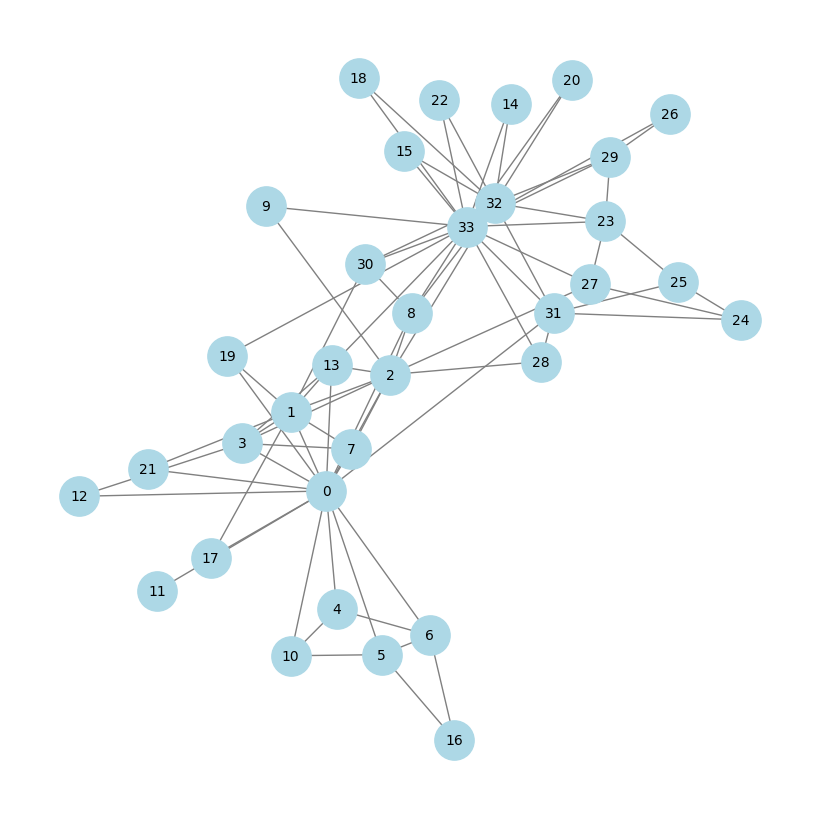

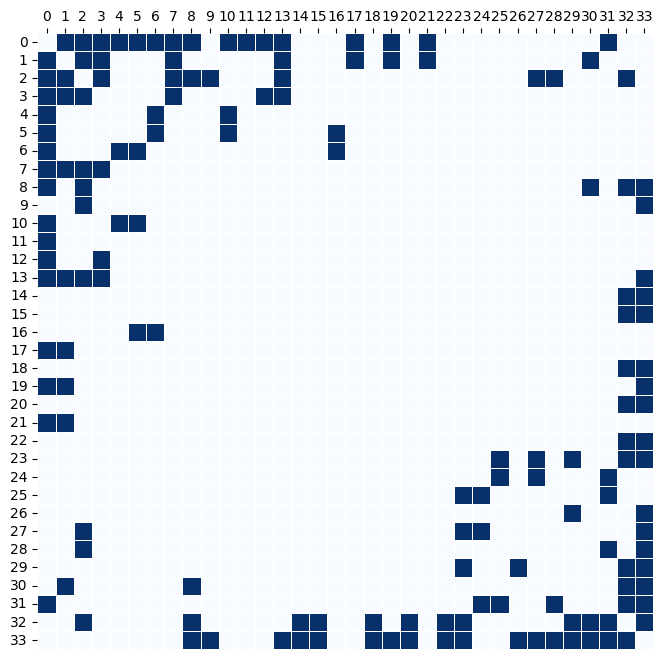

In [2]:
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=10)
plt.show()
Y = nx.to_numpy_array(G, dtype=float)
Y = (Y > 0).astype(int)

plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=10)
plt.show()

In [3]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

Multi_start (1)


MAP:  16%|█▌        | 3920/25000 [00:28<02:35, 135.64it/s, logpost=-202.8324, loglik=-202.2132, logprior=-0.6192, ||grad||=0.0139, patience=100]


[STOP] Early stopping at iter 3919 (no improvement in 101 steps)

Best log-posterior: -202.8324


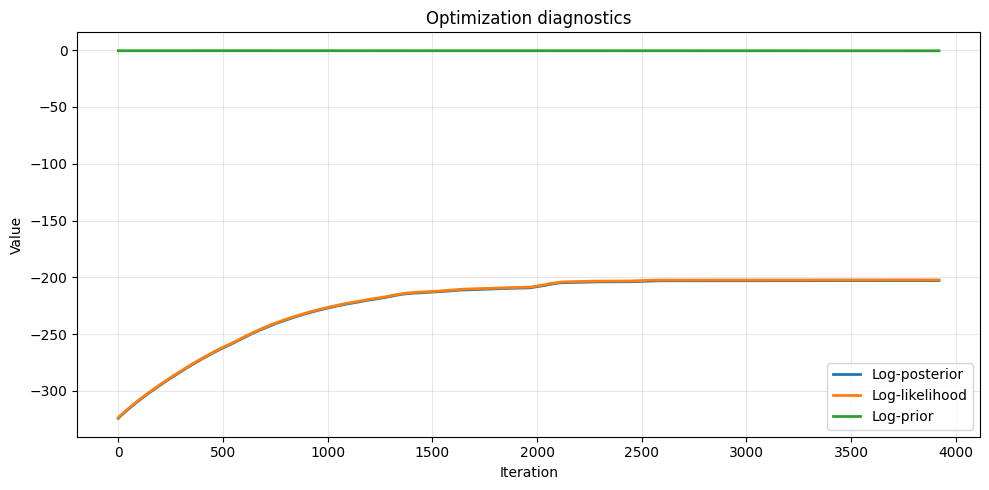

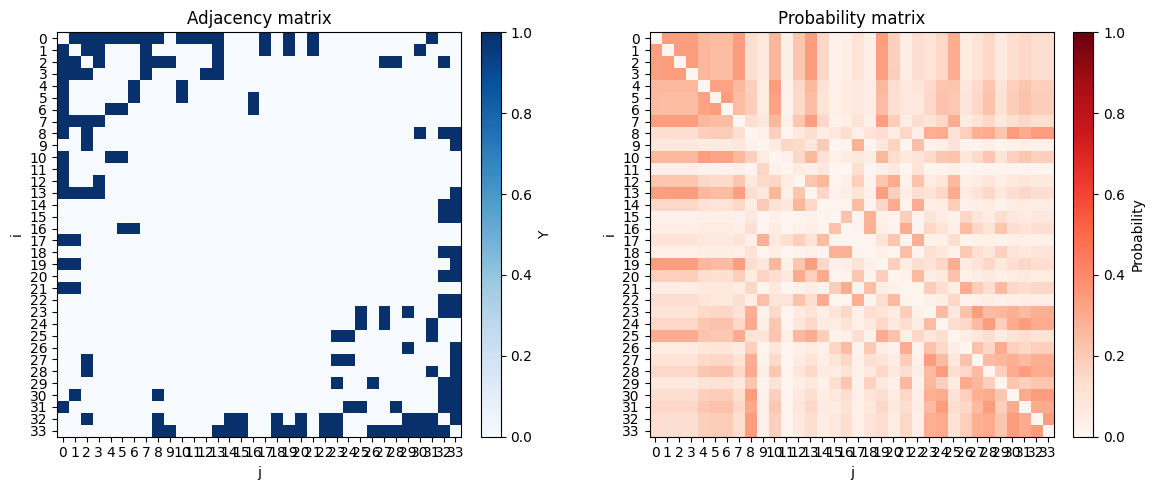

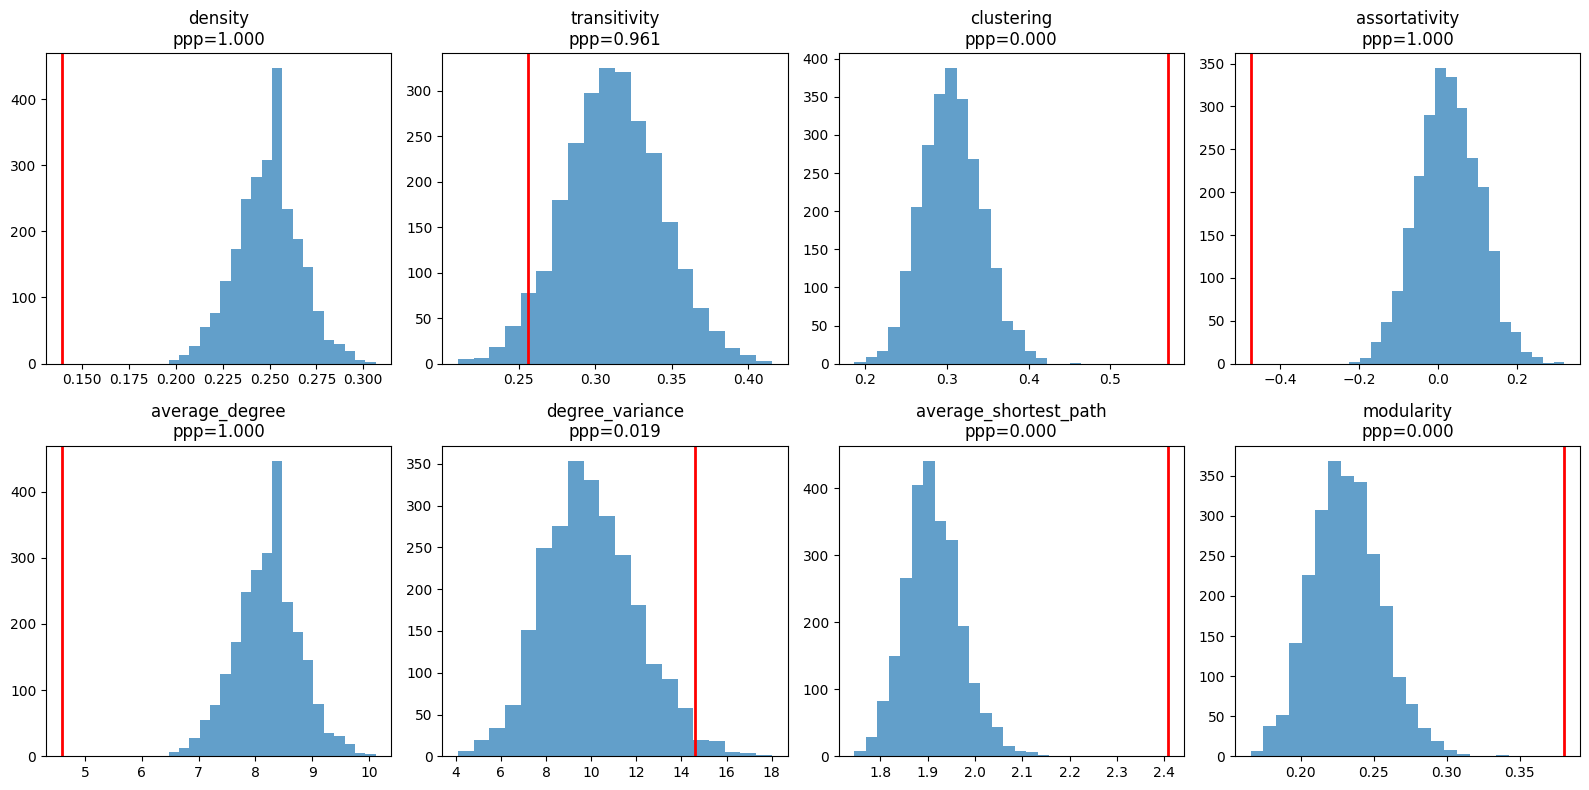

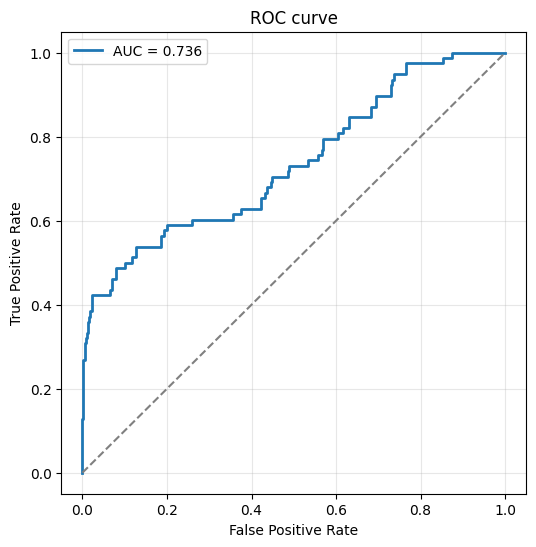

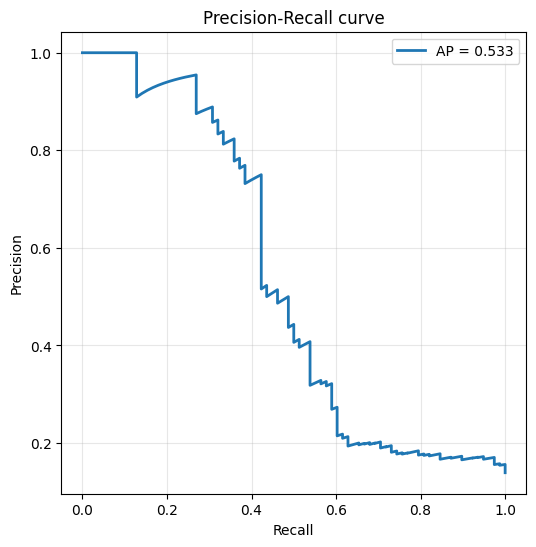

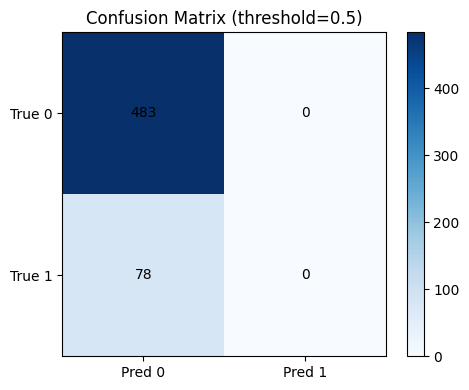

MAP: 100%|██████████| 1000/1000 [00:07<00:00, 132.45it/s, logpost=-150.4065, loglik=-149.8284, logprior=-0.5782, ||grad||=0.0137, patience=0]


{'mean_auc': 0.6385495173760479, 'std_auc': 0.0785961082107489, 'min_auc': np.float64(0.5393586005830904), 'max_auc': np.float64(0.7175), 'n_folds': 5}


In [4]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R1_c.pkl")

#### With weights

Multi_start (1)


MAP:  31%|███       | 7636/25000 [00:35<01:20, 215.17it/s, logpost=-178.5074, loglik=-178.5074, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 7635 (no improvement in 101 steps)

Best log-posterior: -178.5074


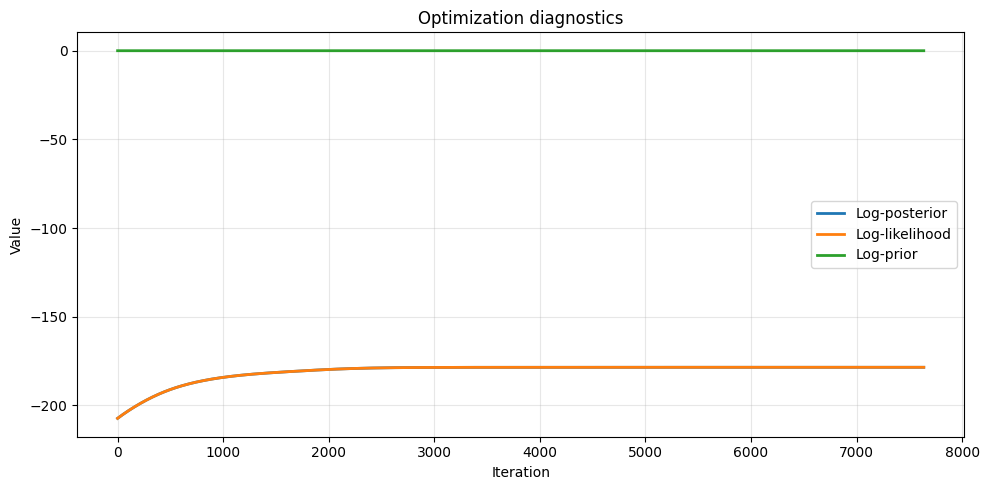

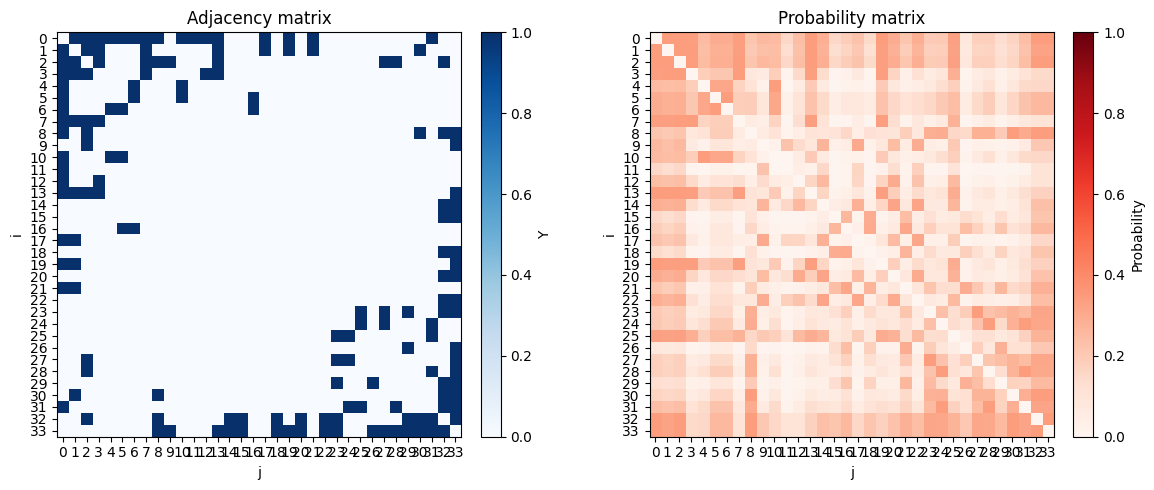

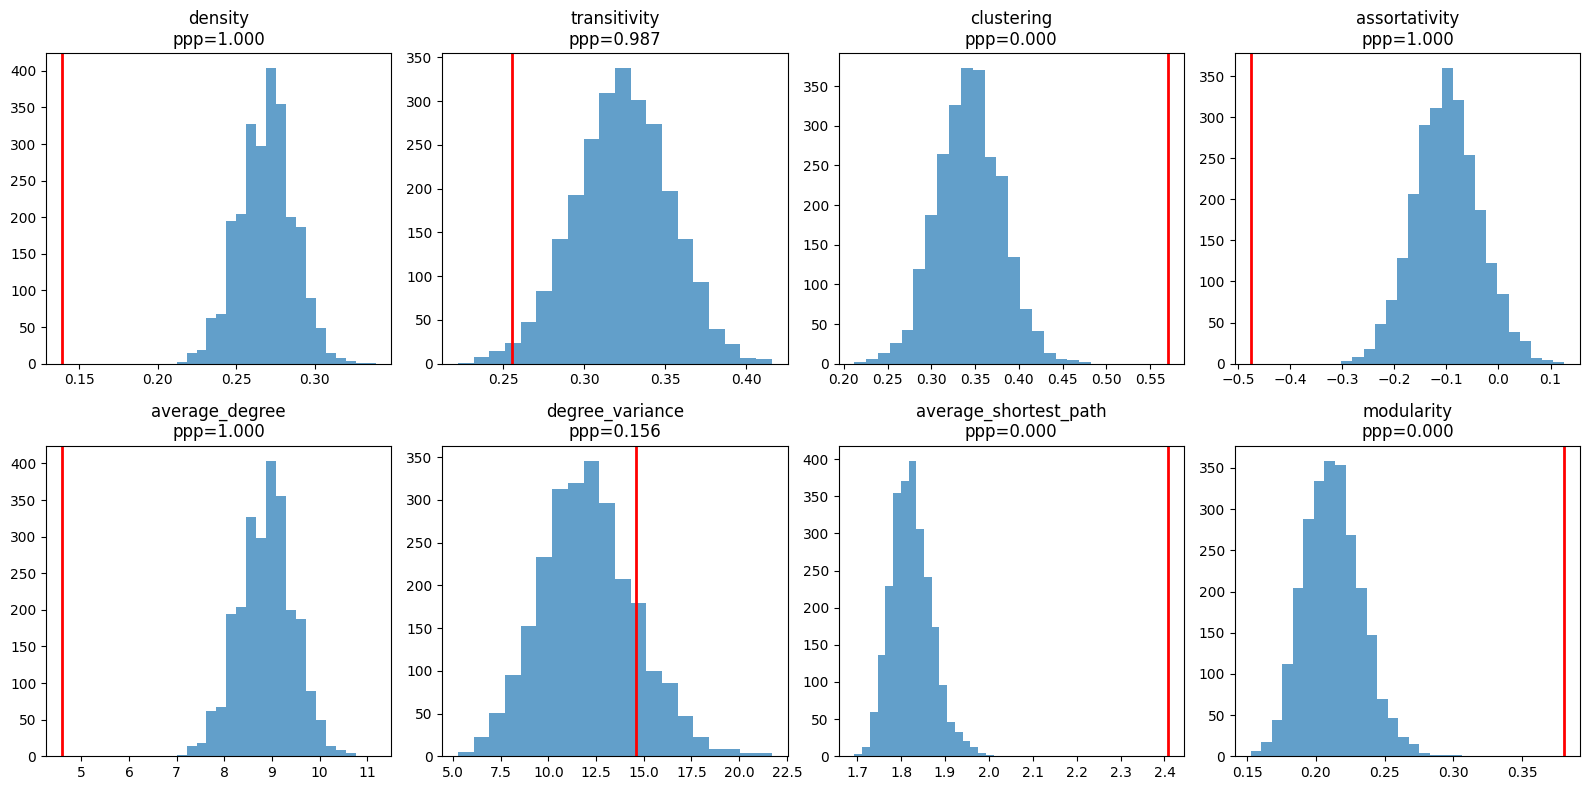

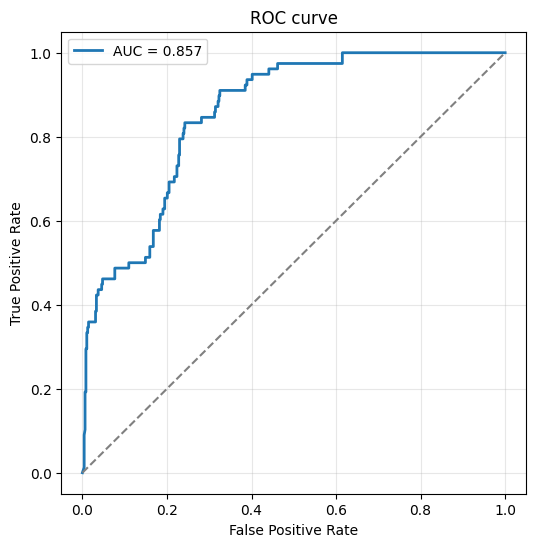

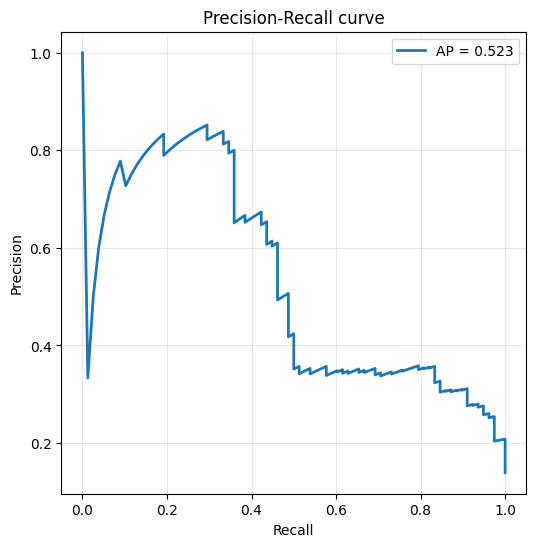

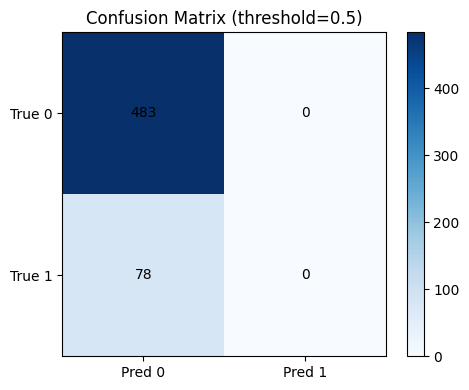

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 190.49it/s, logpost=-143.4932, loglik=-143.4932, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.7971348917522387, 'std_auc': 0.03332693816388656, 'min_auc': np.float64(0.7572727272727273), 'max_auc': np.float64(0.83875), 'n_folds': 5}


In [5]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

Multi_start (1)


MAP:  72%|███████▏  | 17905/25000 [01:33<00:37, 191.28it/s, logpost=-131.9477, loglik=-130.9160, logprior=-1.0317, ||grad||=0.0138, patience=100]


[STOP] Early stopping at iter 17904 (no improvement in 101 steps)

Best log-posterior: -131.9477


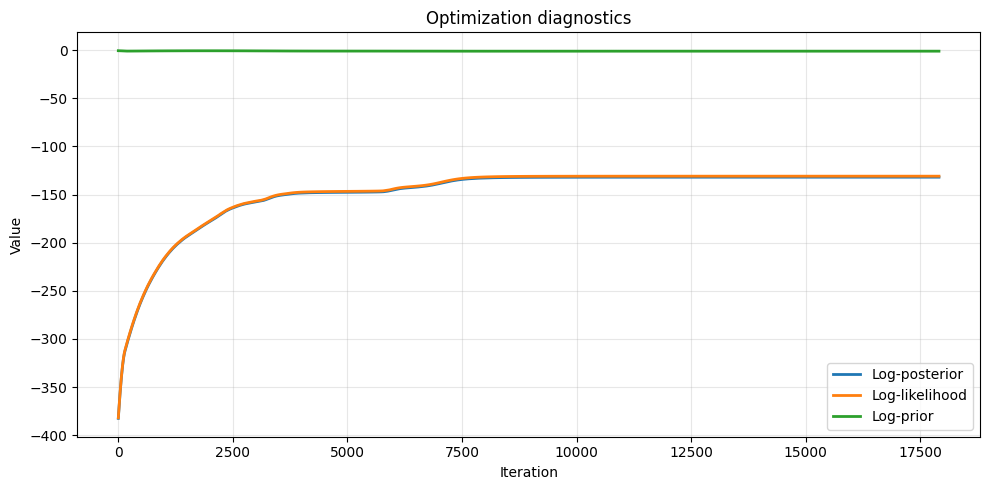

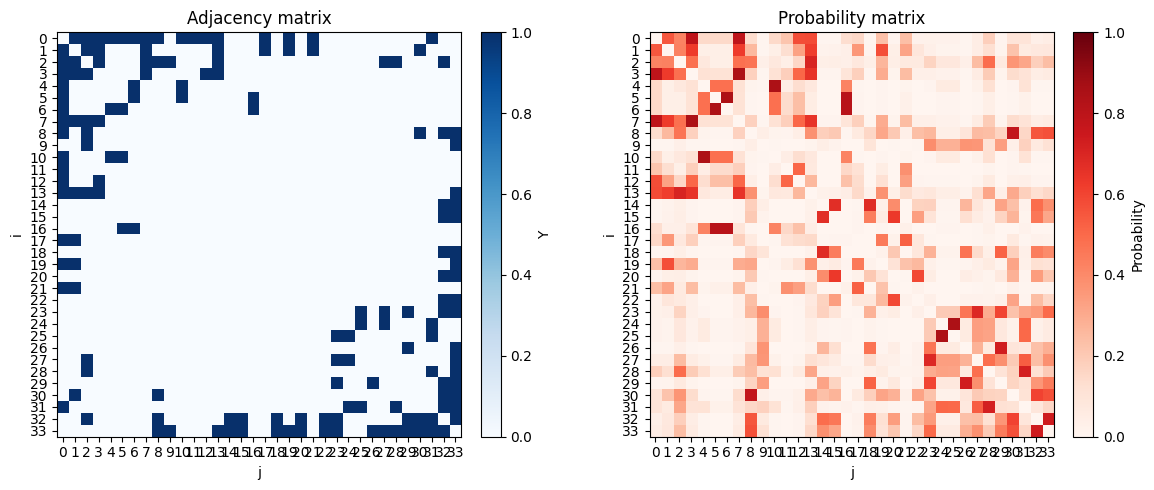

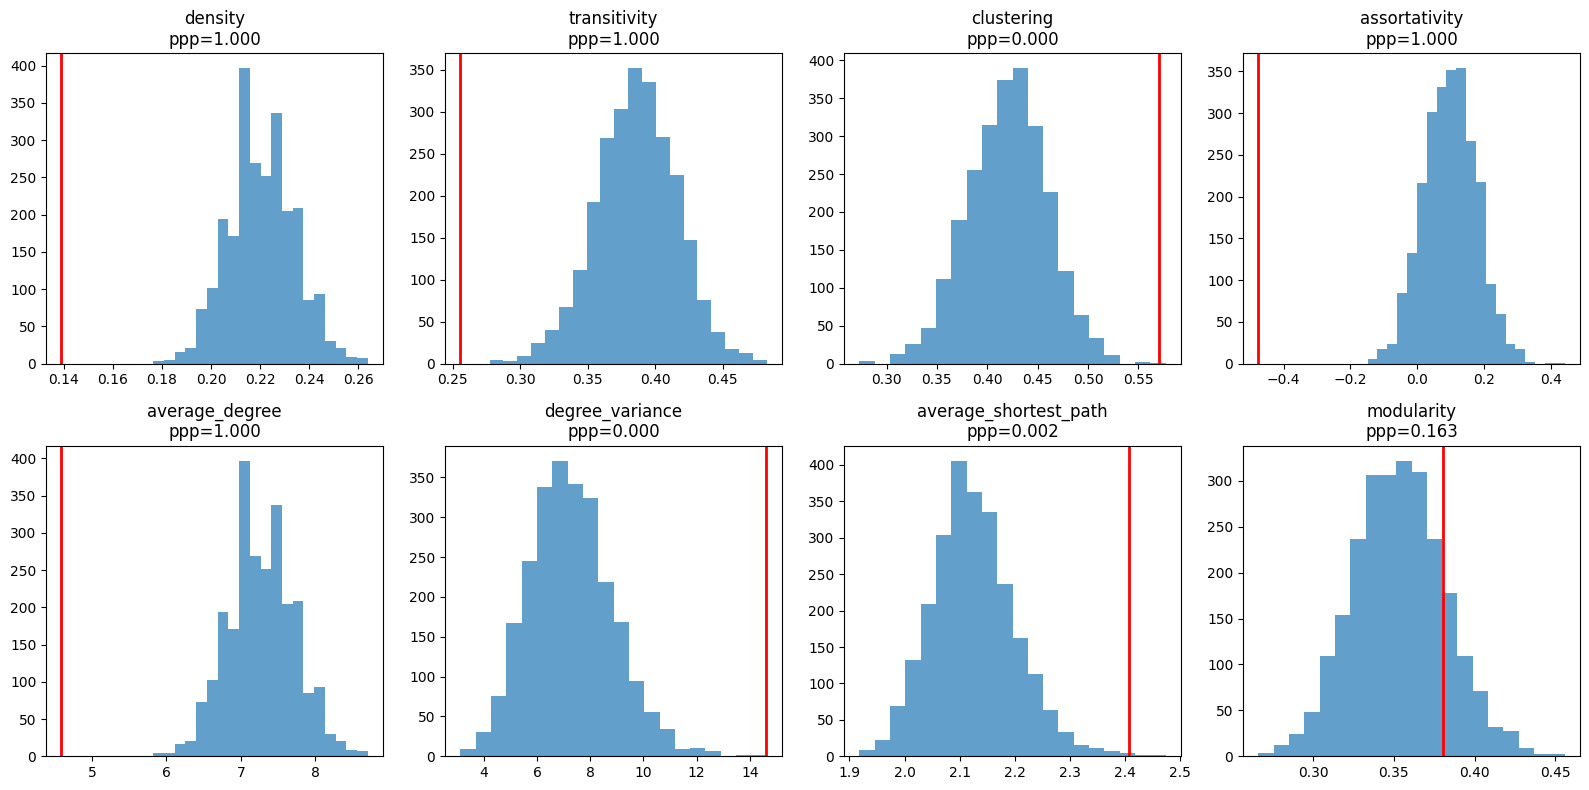

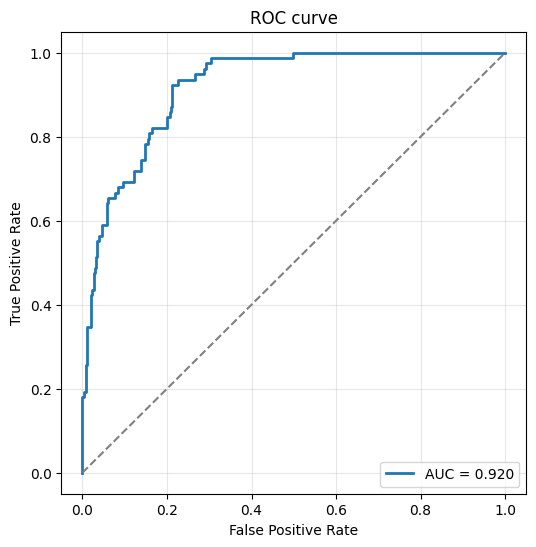

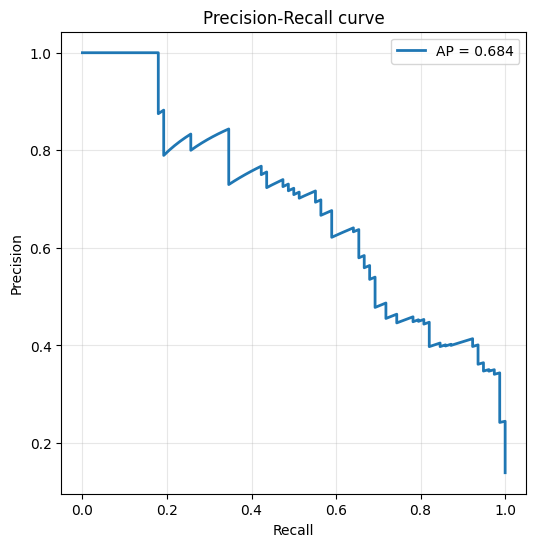

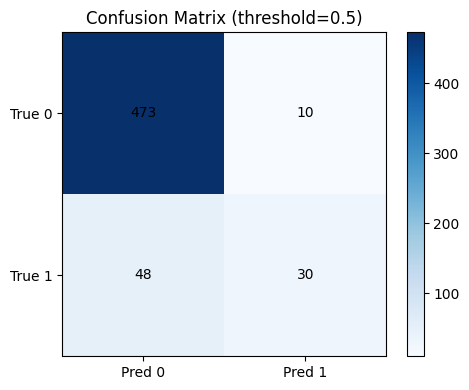

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 193.95it/s, logpost=-102.1275, loglik=-101.1405, logprior=-0.9870, ||grad||=0.0137, patience=0]


{'mean_auc': 0.809891506452731, 'std_auc': 0.019469188362845523, 'min_auc': np.float64(0.7740524781341108), 'max_auc': np.float64(0.8250728862973761), 'n_folds': 5}


In [6]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R2_c.pkl")

#### With weights

Multi_start (1)


MAP:   9%|▉         | 2335/25000 [00:07<01:12, 311.37it/s, logpost=-102.2693, loglik=-102.2693, logprior=0.0000, ||grad||=0.0099, patience=100]


[STOP] Early stopping at iter 2334 (no improvement in 101 steps)

Best log-posterior: -102.2693


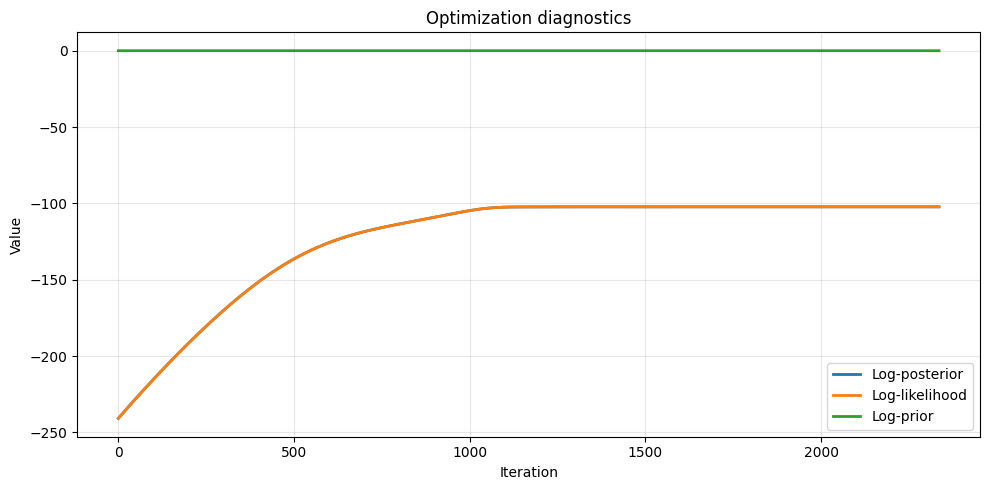

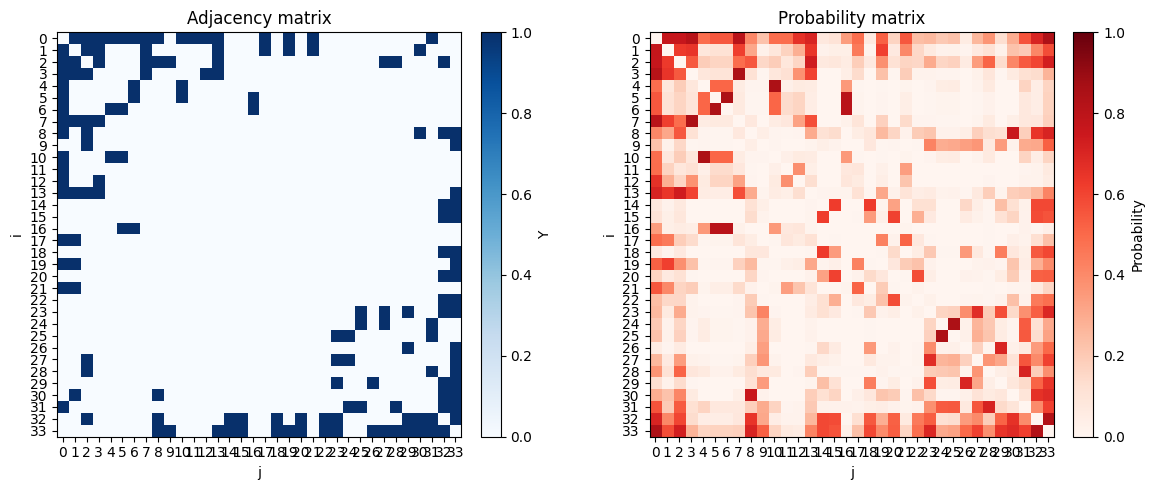

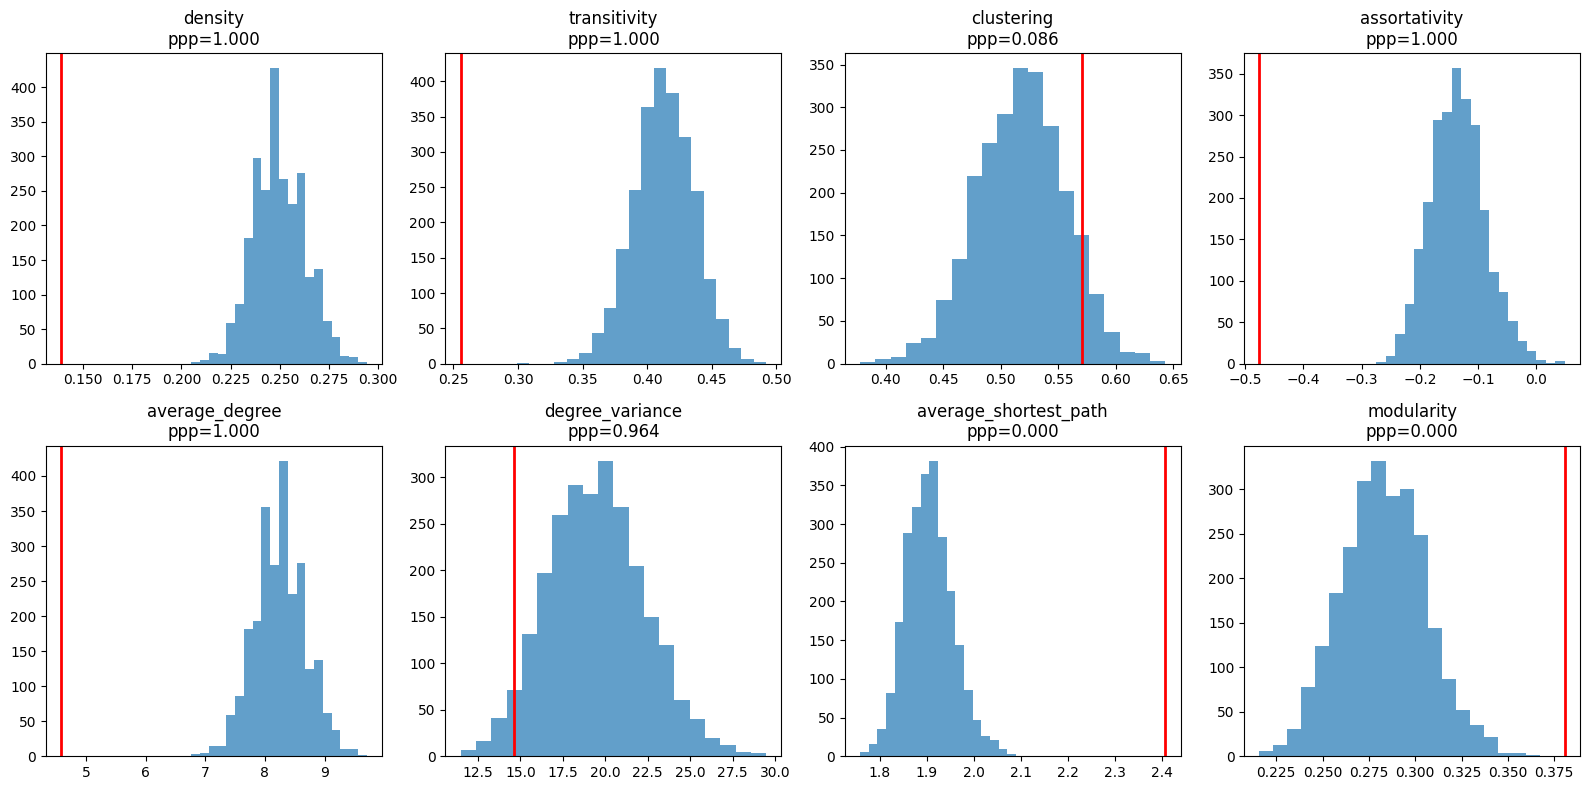

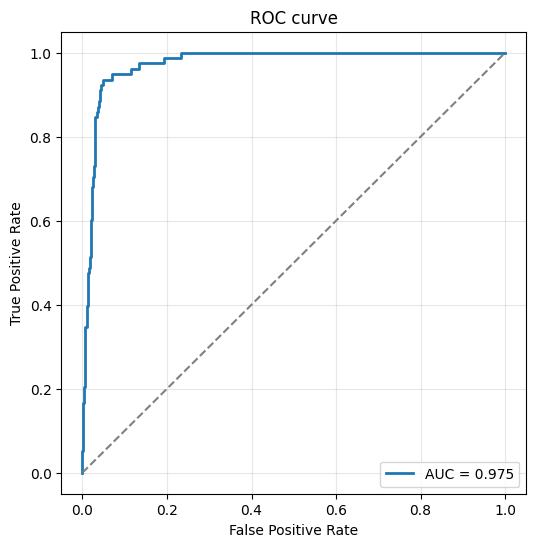

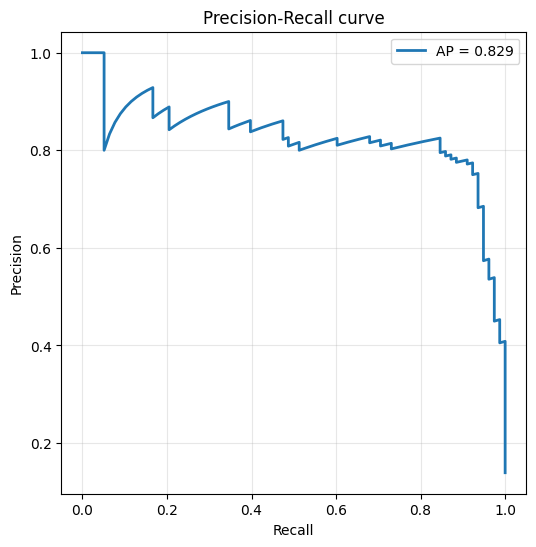

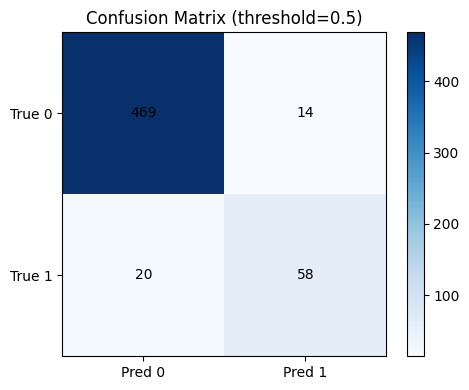

MAP:  95%|█████████▌| 953/1000 [00:03<00:00, 281.82it/s, logpost=-82.2256, loglik=-82.2256, logprior=0.0000, ||grad||=0.0099, patience=49]


{'mean_auc': 0.9509508462059483, 'std_auc': 0.01460711616135433, 'min_auc': np.float64(0.9355089355089355), 'max_auc': np.float64(0.978134110787172), 'n_folds': 5}


In [7]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [02:05<00:00, 199.96it/s, logpost=-112.1591, loglik=-110.4517, logprior=-1.7073, ||grad||=0.0138, patience=0]



Best log-posterior: -112.1591


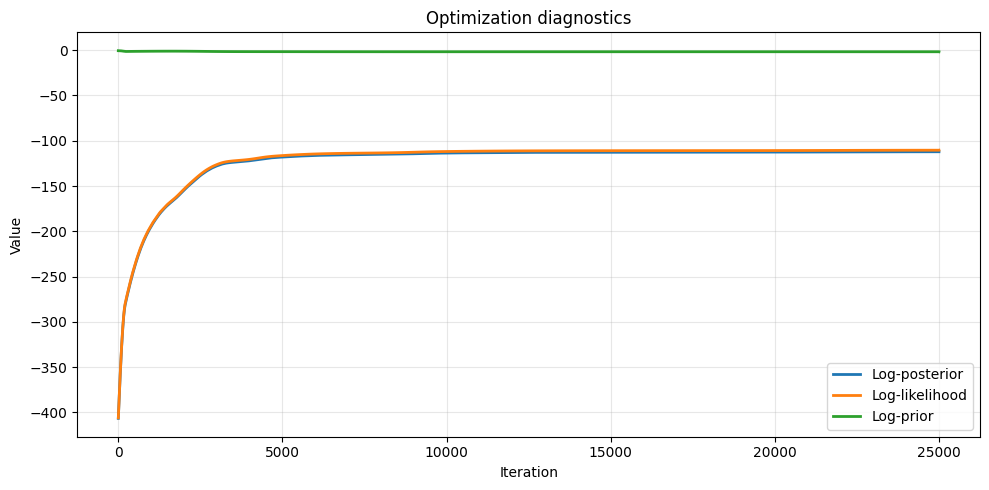

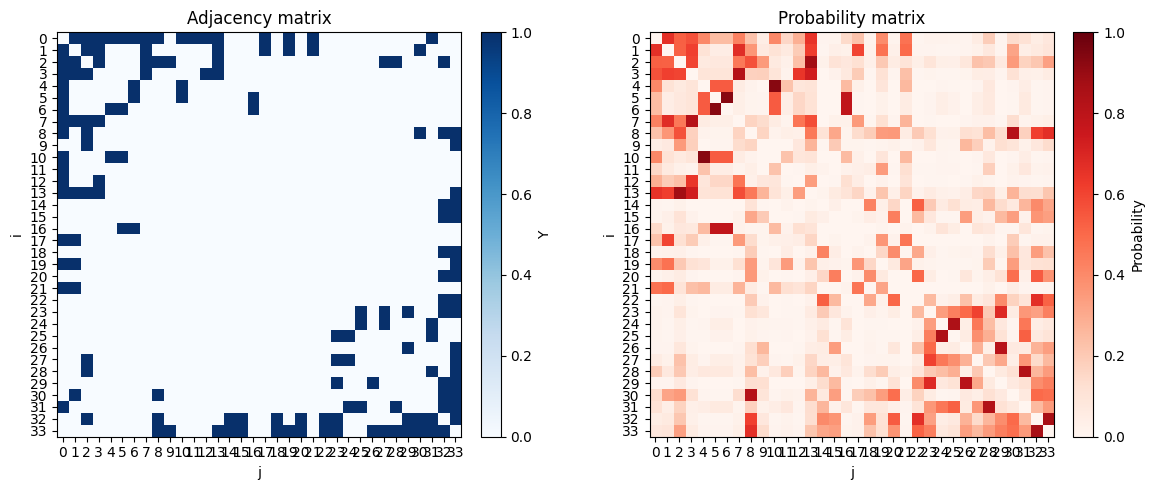

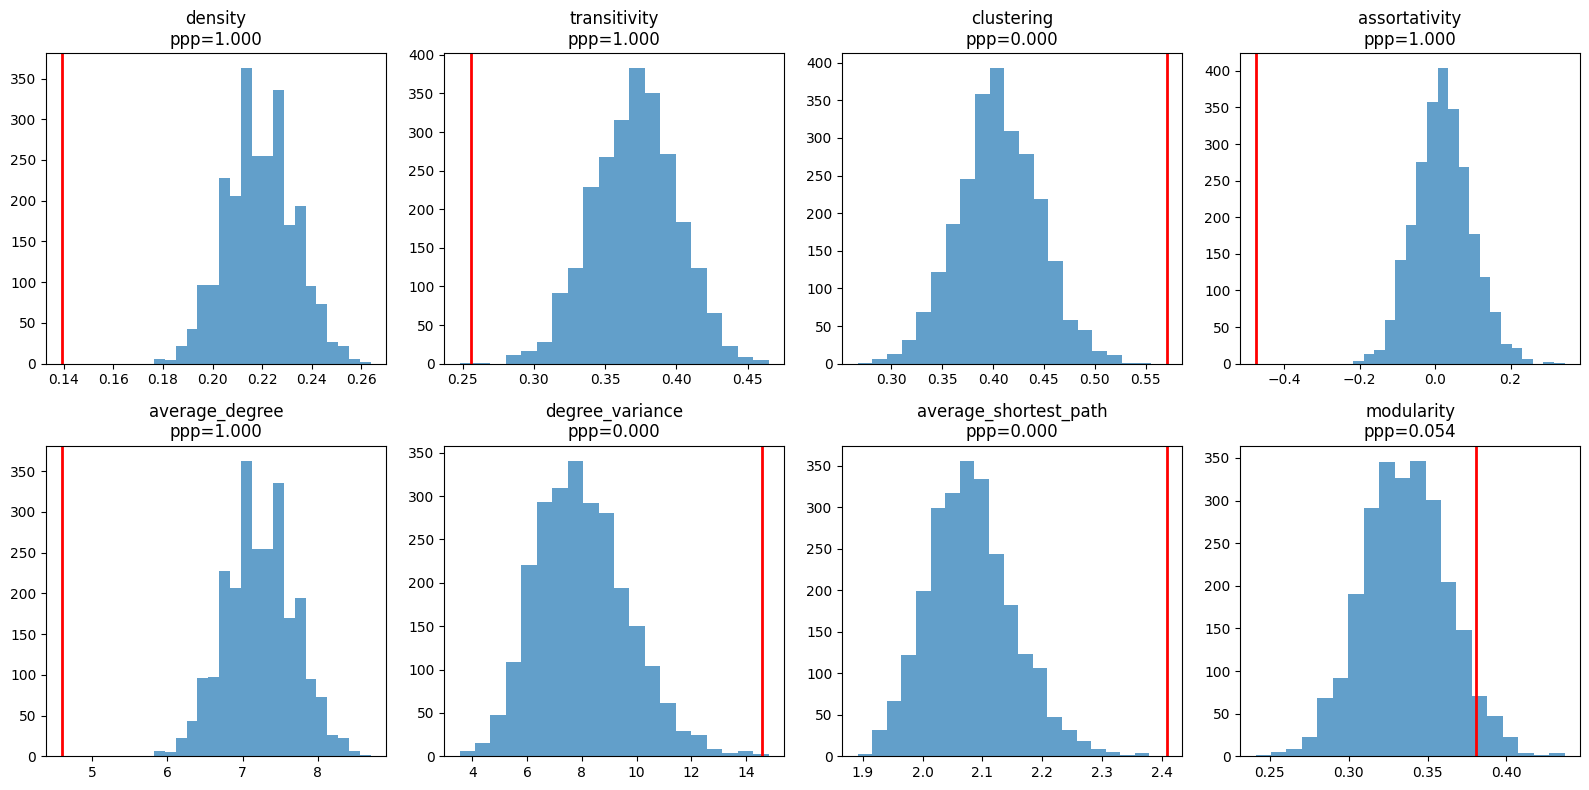

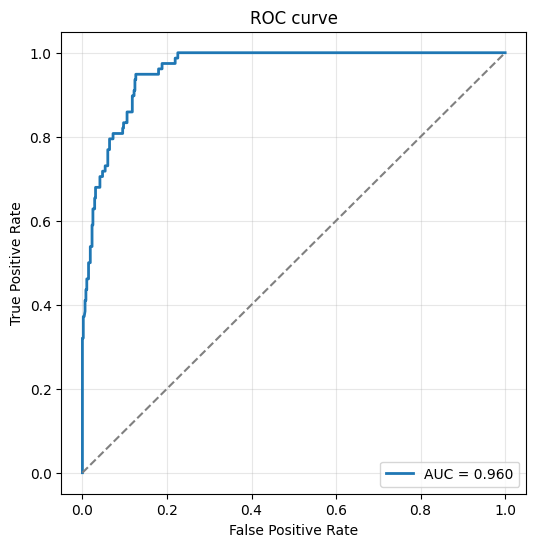

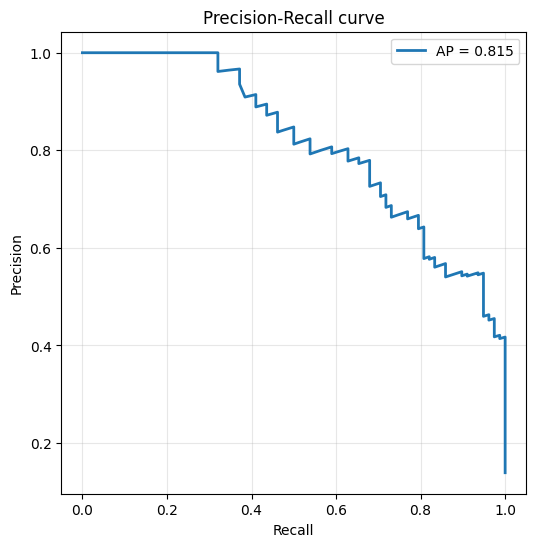

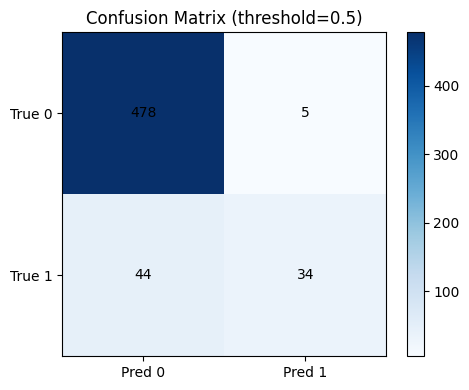

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 202.31it/s, logpost=-88.8639, loglik=-87.1812, logprior=-1.6827, ||grad||=0.0137, patience=0]


{'mean_auc': 0.8496901454554516, 'std_auc': 0.035326427480036005, 'min_auc': np.float64(0.8104118104118104), 'max_auc': np.float64(0.9045189504373178), 'n_folds': 5}


In [8]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R3_c.pkl")

#### With weights

Multi_start (1)


MAP:   5%|▍         | 1135/25000 [00:03<01:21, 294.37it/s, logpost=-87.0974, loglik=-87.0974, logprior=0.0000, ||grad||=0.0086, patience=100]


[STOP] Early stopping at iter 1134 (no improvement in 101 steps)

Best log-posterior: -87.0974


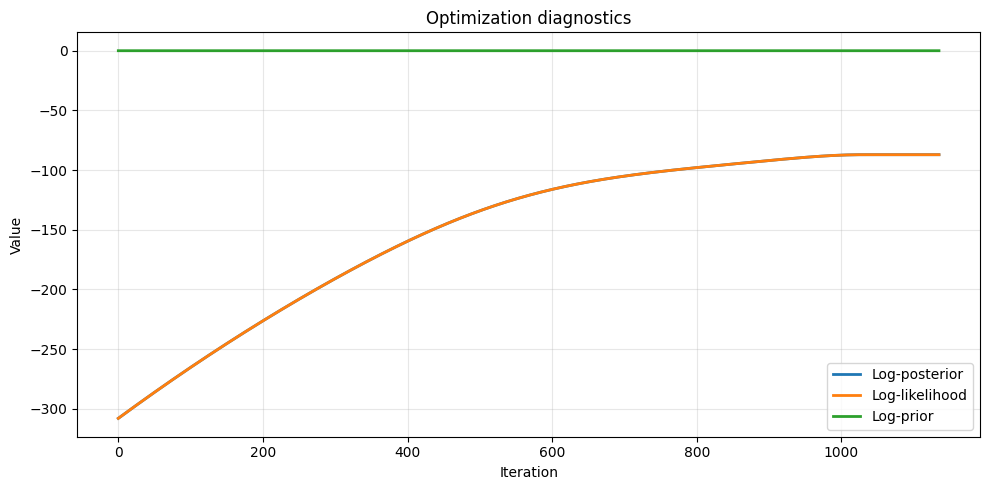

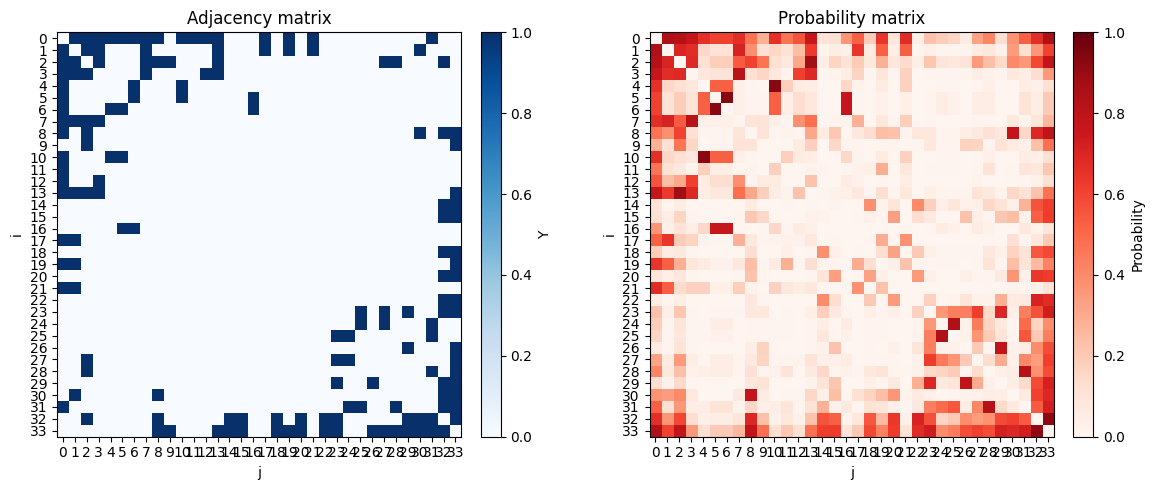

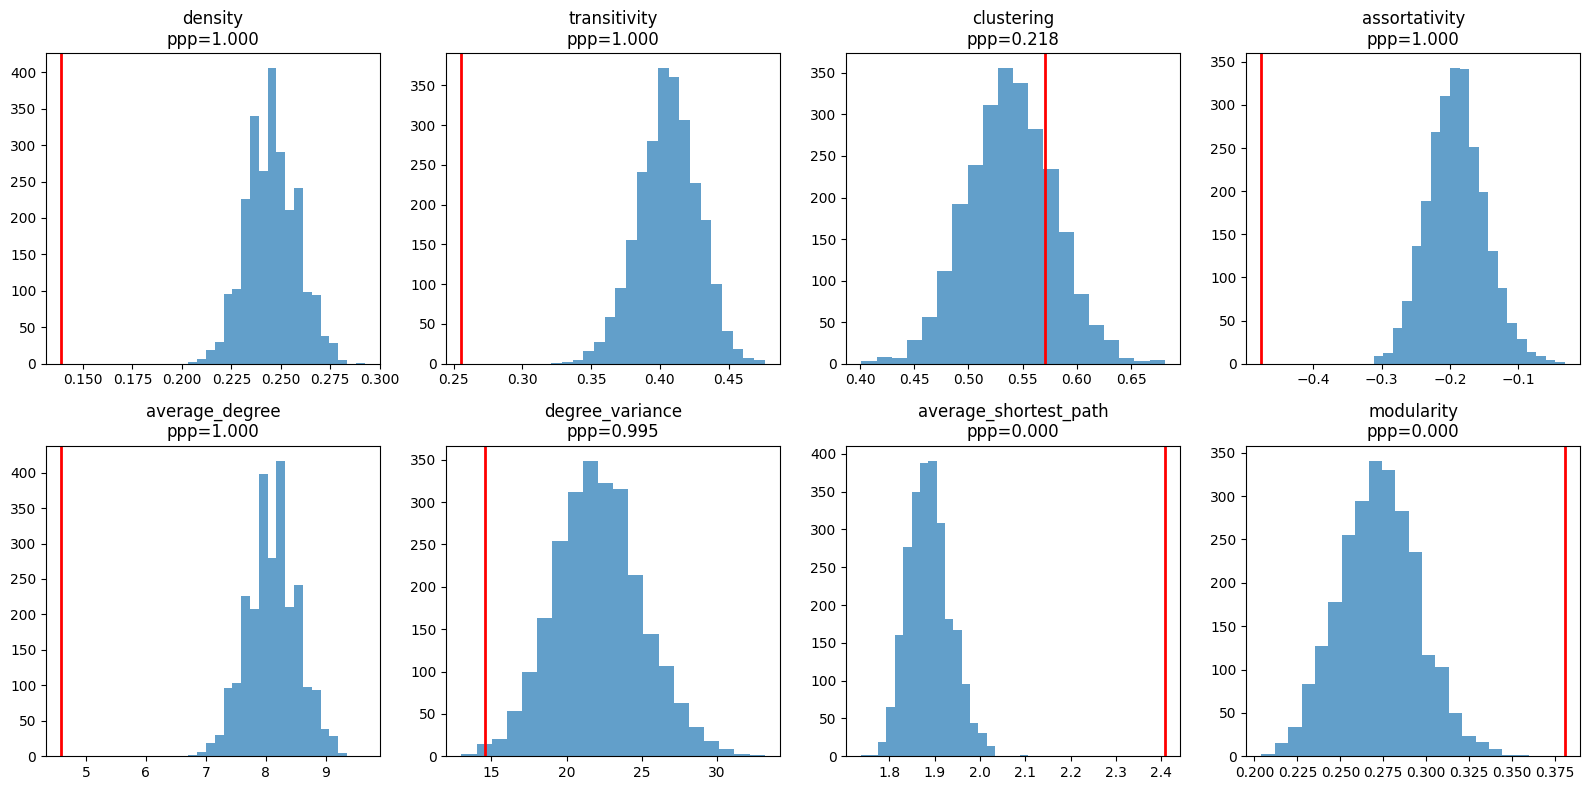

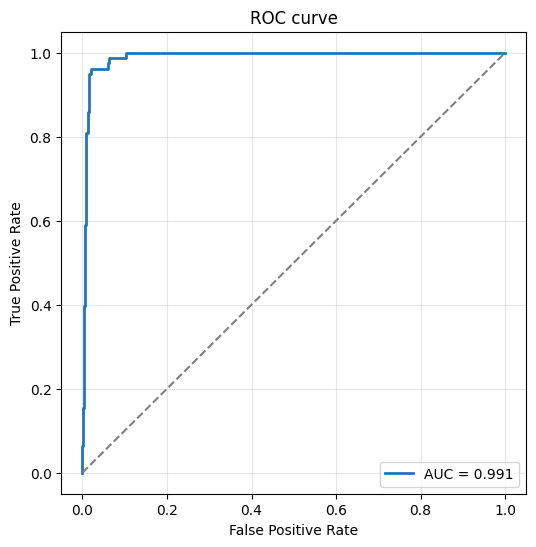

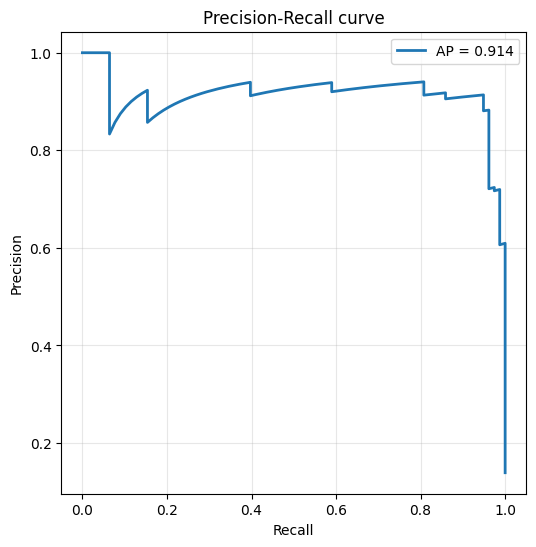

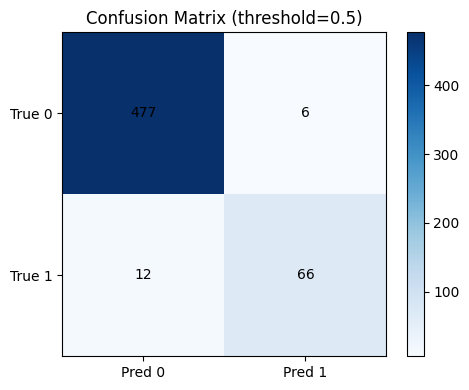

MAP:  12%|█▏        | 120/1000 [00:00<00:06, 127.00it/s, logpost=-70.8590, loglik=-70.8590, logprior=0.0000, ||grad||=0.0084, patience=49]


{'mean_auc': 0.9779915390731718, 'std_auc': 0.010770044042180649, 'min_auc': np.float64(0.9627039627039627), 'max_auc': np.float64(0.9948979591836734), 'n_folds': 5}


In [9]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

In [11]:
with open("Karate_R2_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:  30%|███       | 7584/25000 [00:39<01:30, 191.88it/s, logpost=-164.8543, loglik=-164.2969, logprior=-0.5573, ||grad||=0.0138, patience=100]


[STOP] Early stopping at iter 7583 (no improvement in 101 steps)

Best log-posterior: -164.8543


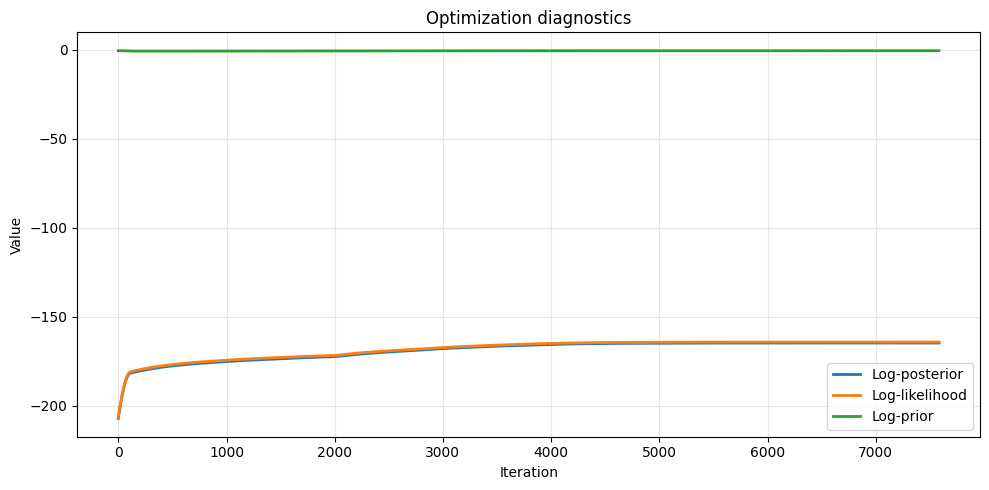

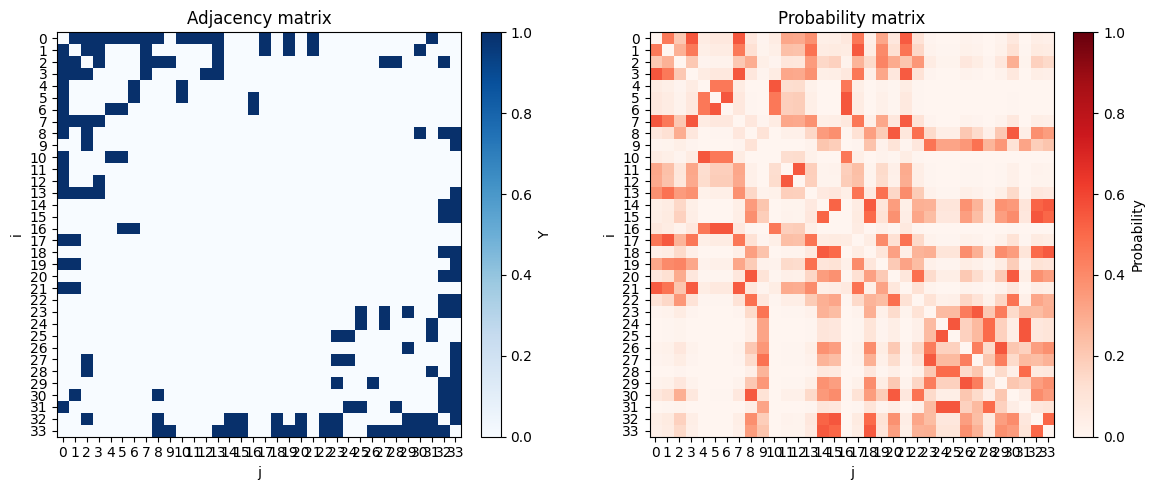

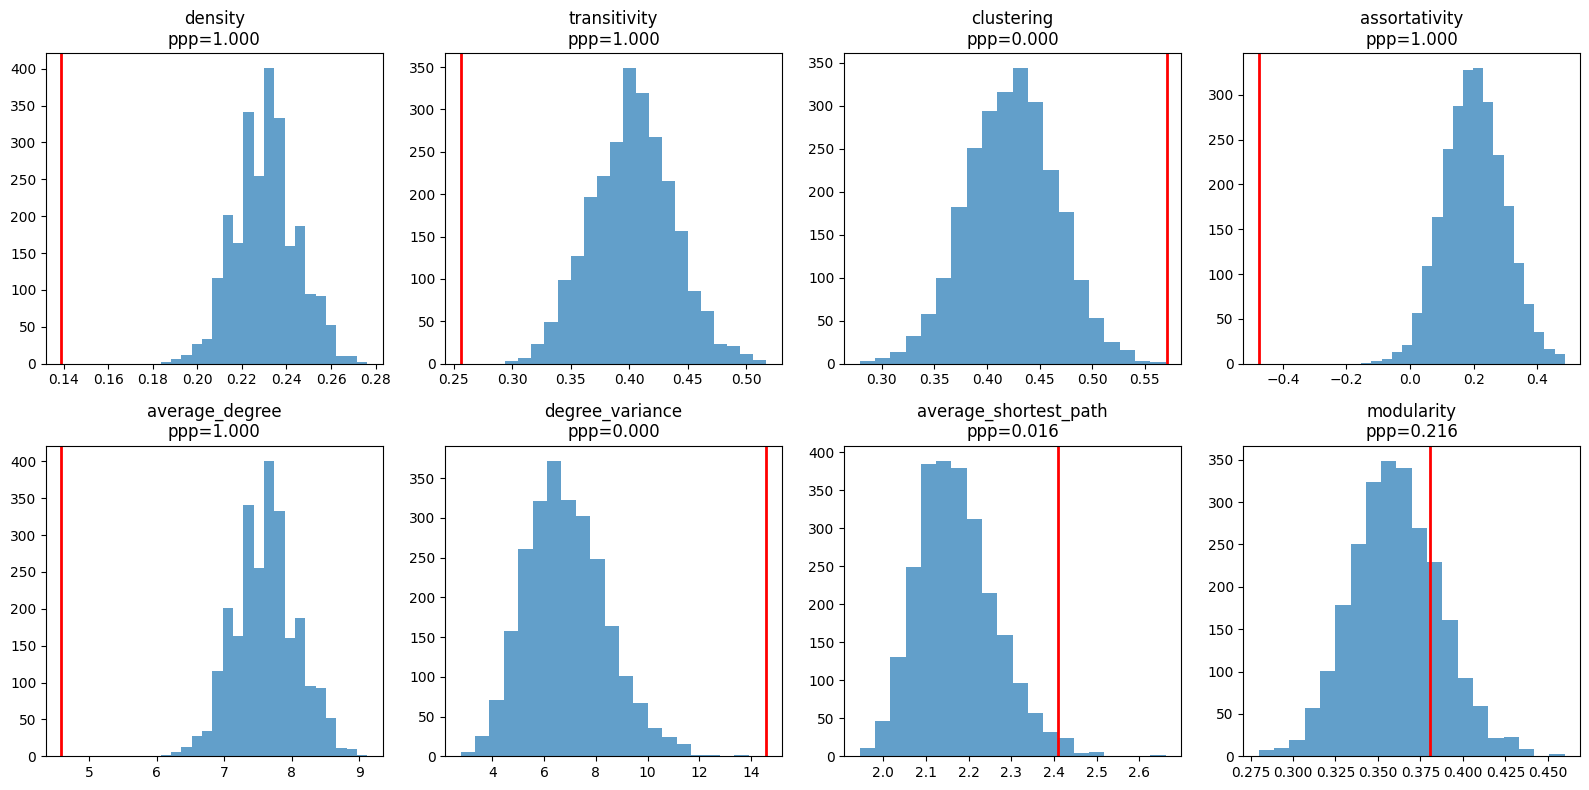

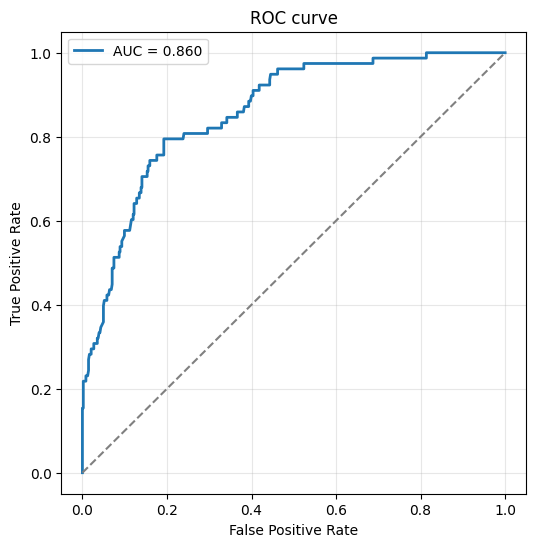

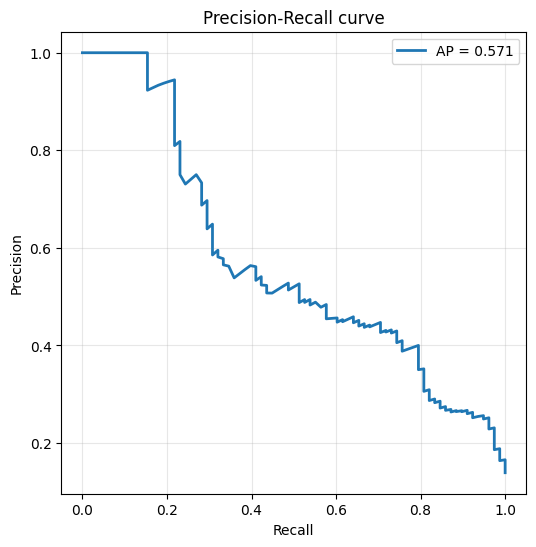

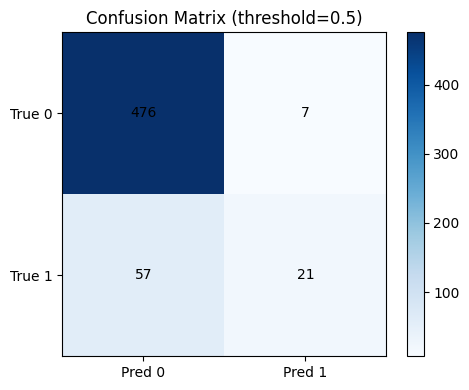

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 197.12it/s, logpost=-132.3941, loglik=-131.8289, logprior=-0.5652, ||grad||=0.0137, patience=2]


{'mean_auc': 0.8001331151841355, 'std_auc': 0.03162630763703026, 'min_auc': np.float64(0.7505827505827506), 'max_auc': np.float64(0.8325), 'n_folds': 5}


In [12]:
geometry = SphericalGeometry(d=1, D=diam)
with open("Karate_R2_c.pkl", "rb") as f:
    results_R2_c = pickle.load(f)
Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R2_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  13%|█▎        | 3194/25000 [00:10<01:11, 306.17it/s, logpost=-130.7708, loglik=-130.7708, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 3193 (no improvement in 101 steps)

Best log-posterior: -130.7708


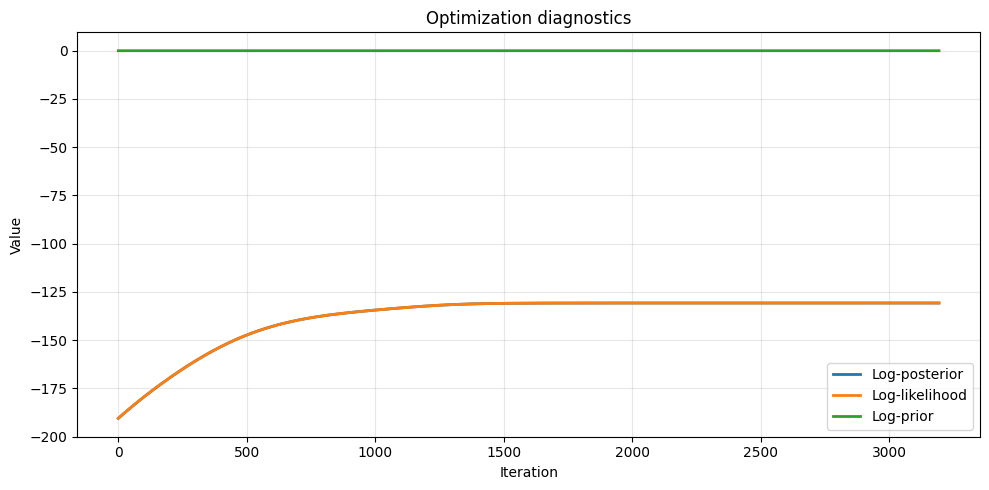

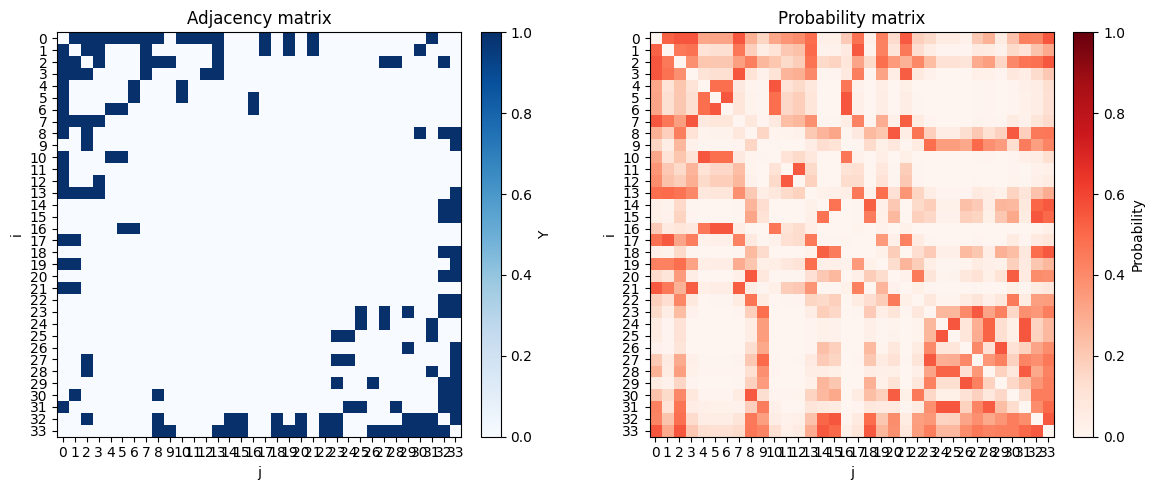

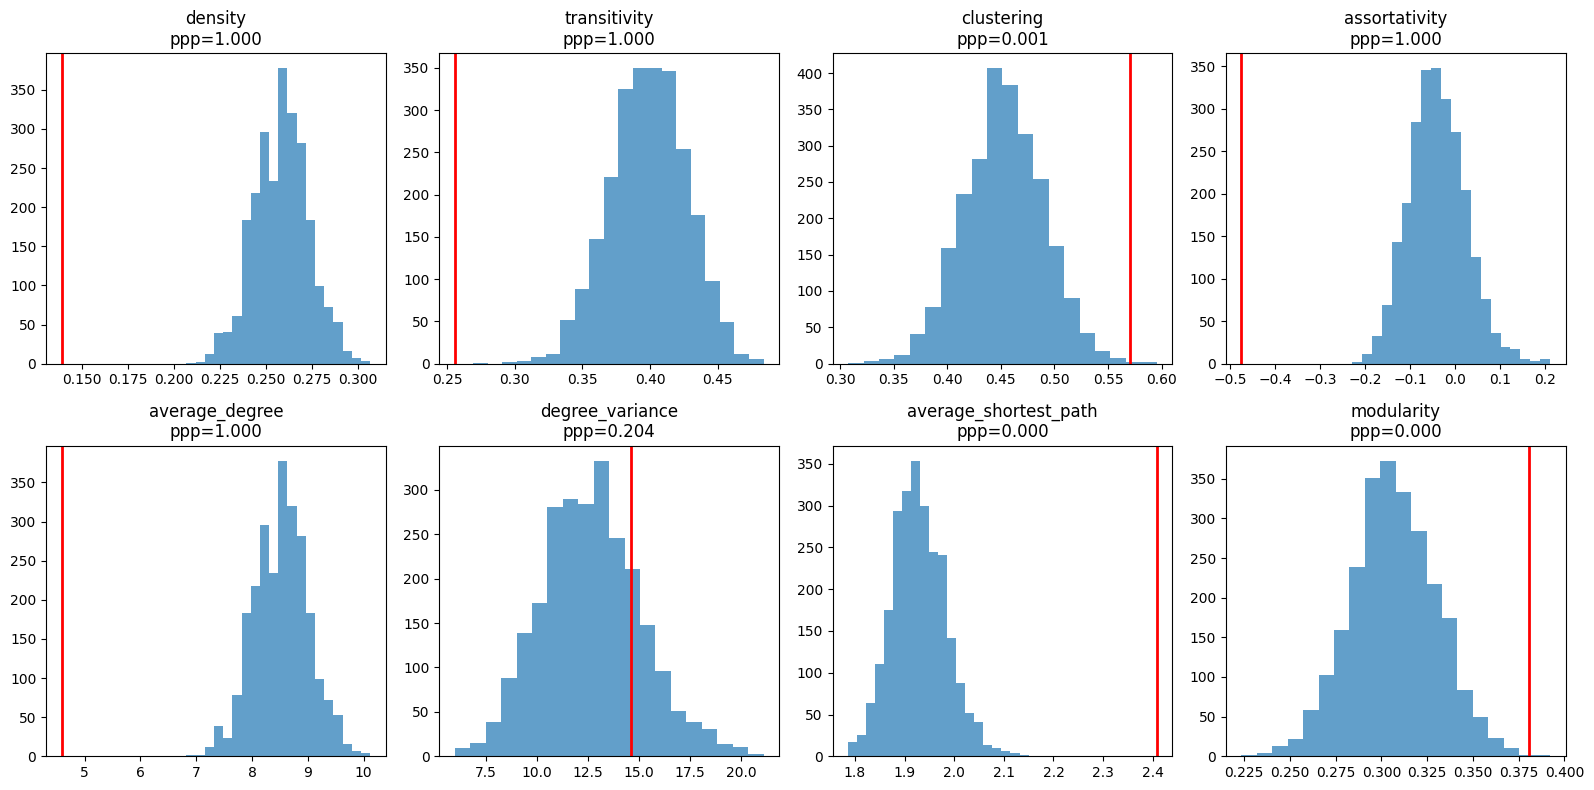

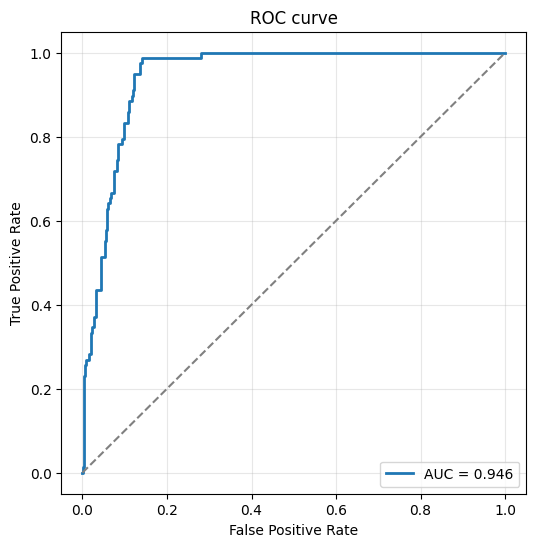

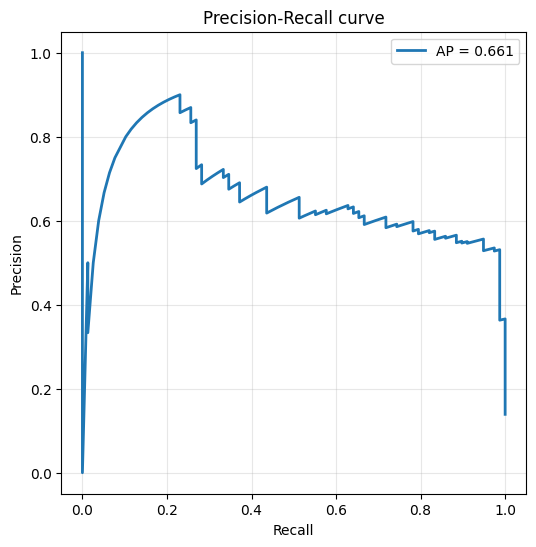

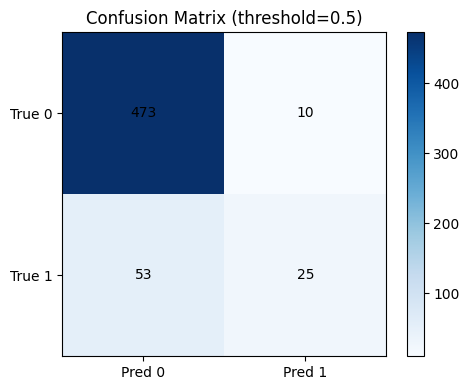

MAP: 100%|██████████| 1000/1000 [00:03<00:00, 294.69it/s, logpost=-106.8068, loglik=-106.8068, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.92076680802191, 'std_auc': 0.02076171604655058, 'min_auc': np.float64(0.8991666666666667), 'max_auc': np.float64(0.9548104956268222), 'n_folds': 5}


In [13]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [14]:
with open("Karate_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

Multi_start (1)


MAP:  37%|███▋      | 9252/25000 [00:47<01:20, 194.65it/s, logpost=-133.4487, loglik=-132.4758, logprior=-0.9729, ||grad||=0.0131, patience=100]


[STOP] Early stopping at iter 9251 (no improvement in 101 steps)

Best log-posterior: -133.4487


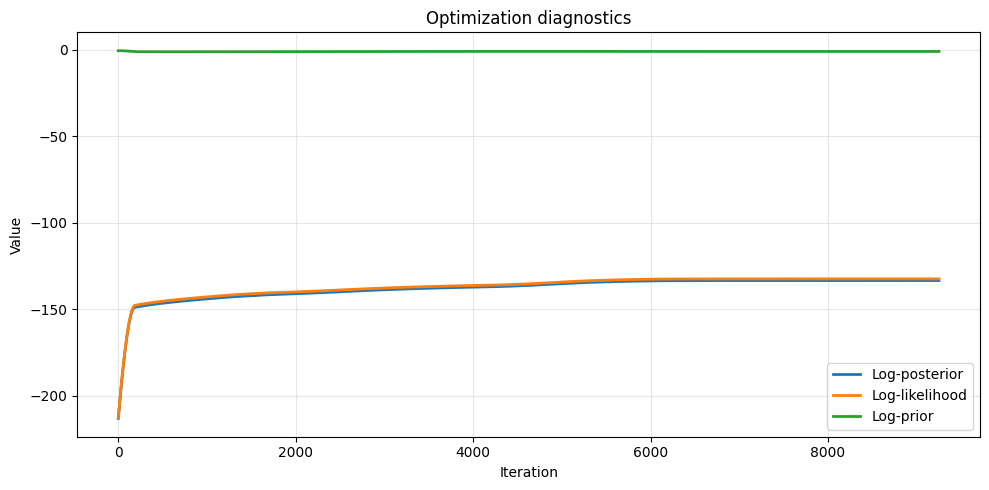

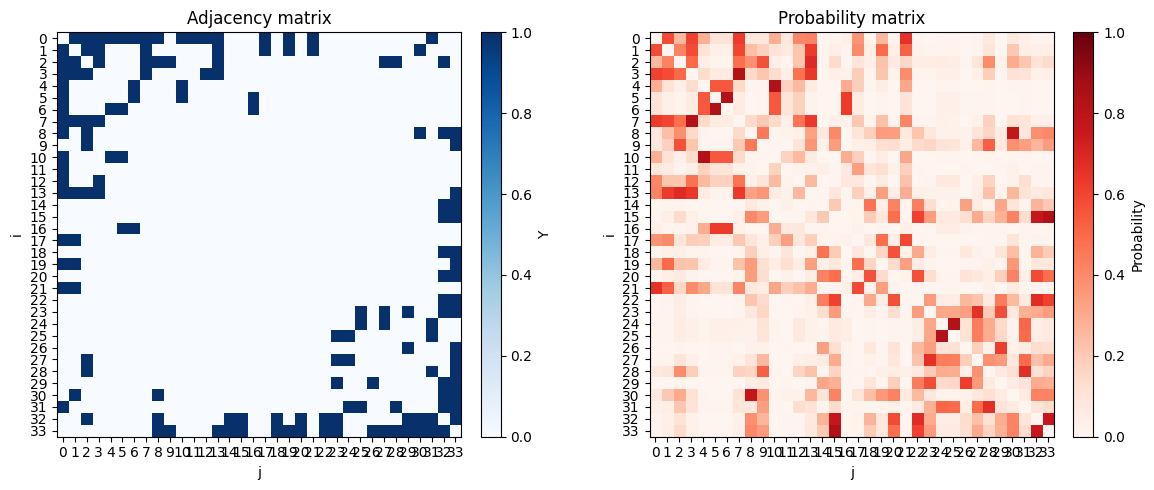

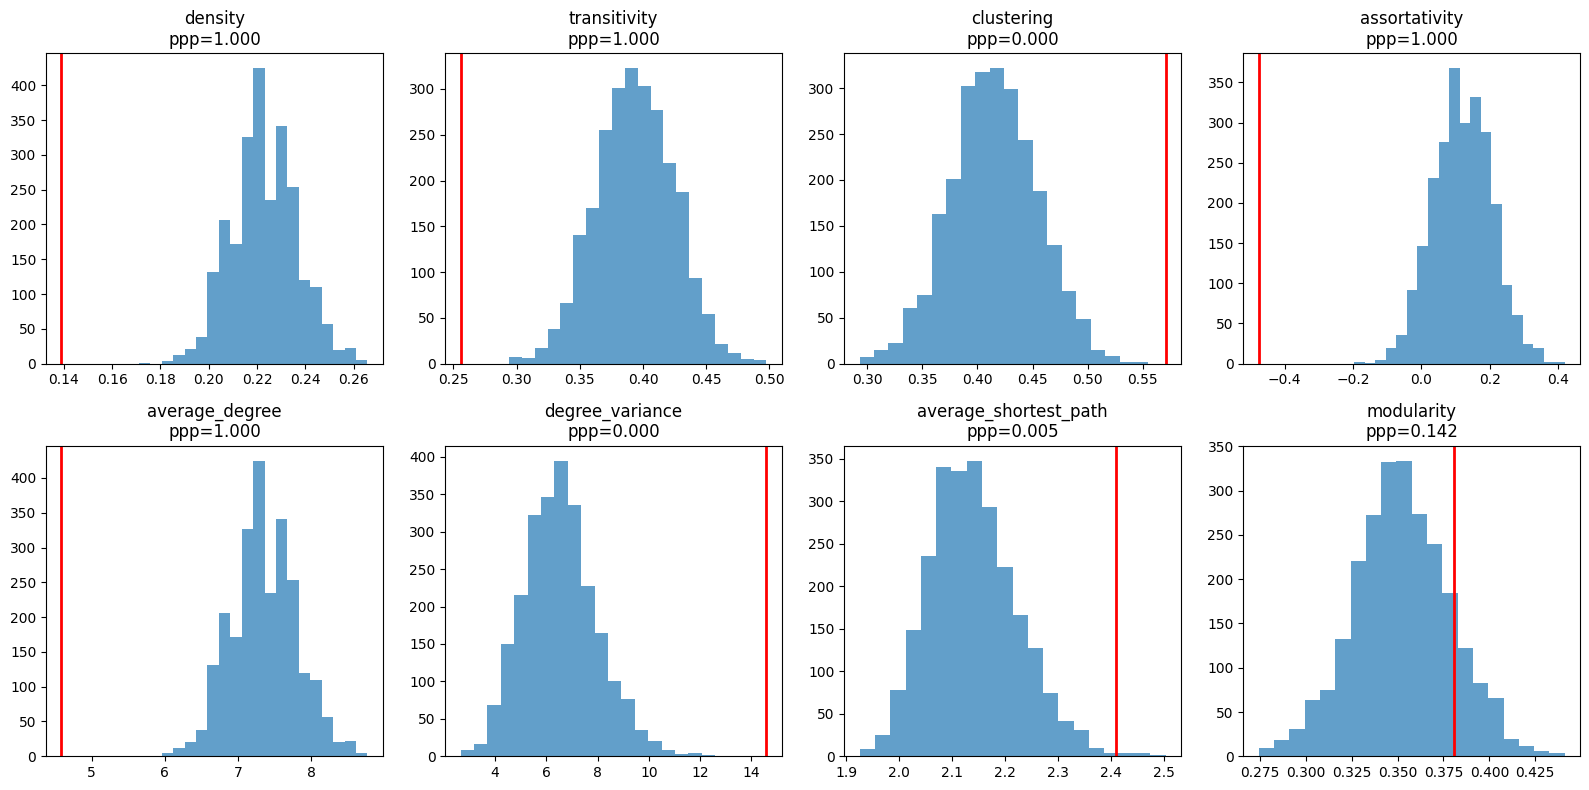

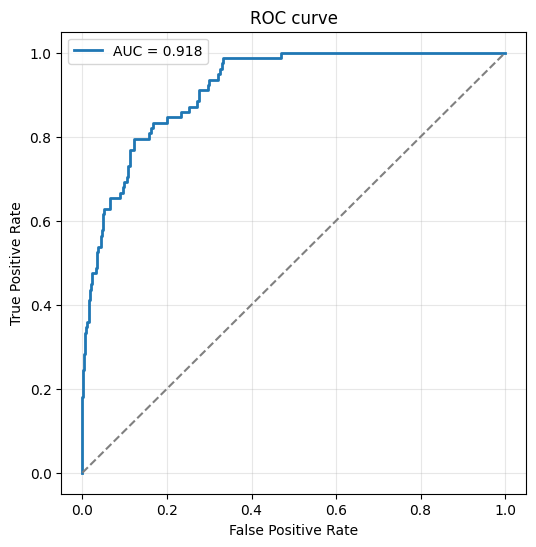

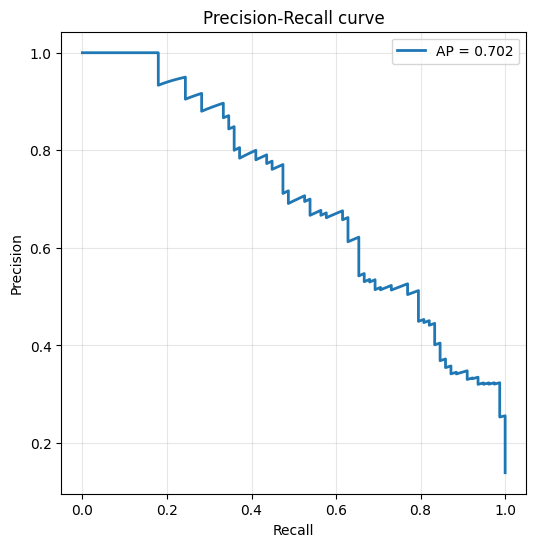

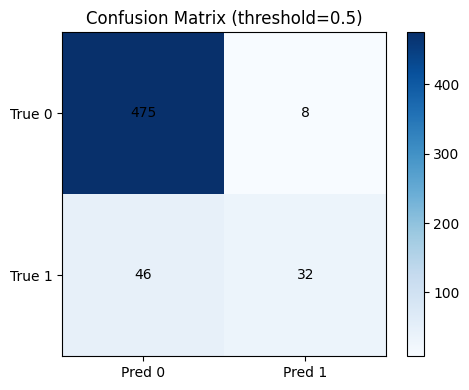

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 185.54it/s, logpost=-103.8719, loglik=-102.8495, logprior=-1.0224, ||grad||=0.0137, patience=0]


{'mean_auc': 0.8226189830577587, 'std_auc': 0.03125541029073838, 'min_auc': np.float64(0.7645687645687647), 'max_auc': np.float64(0.8508333333333333), 'n_folds': 5}


In [15]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  11%|█         | 2697/25000 [00:08<01:09, 321.56it/s, logpost=-97.6592, loglik=-97.6592, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 2696 (no improvement in 101 steps)

Best log-posterior: -97.6592


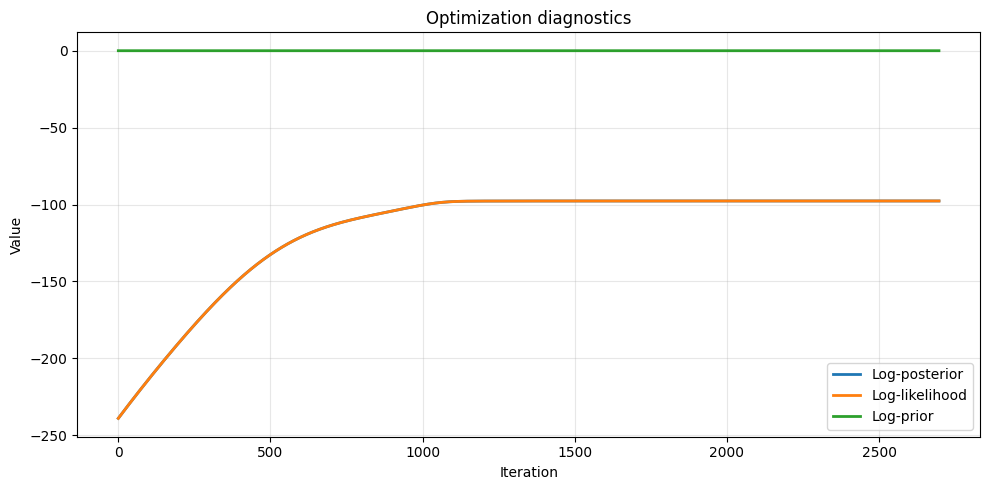

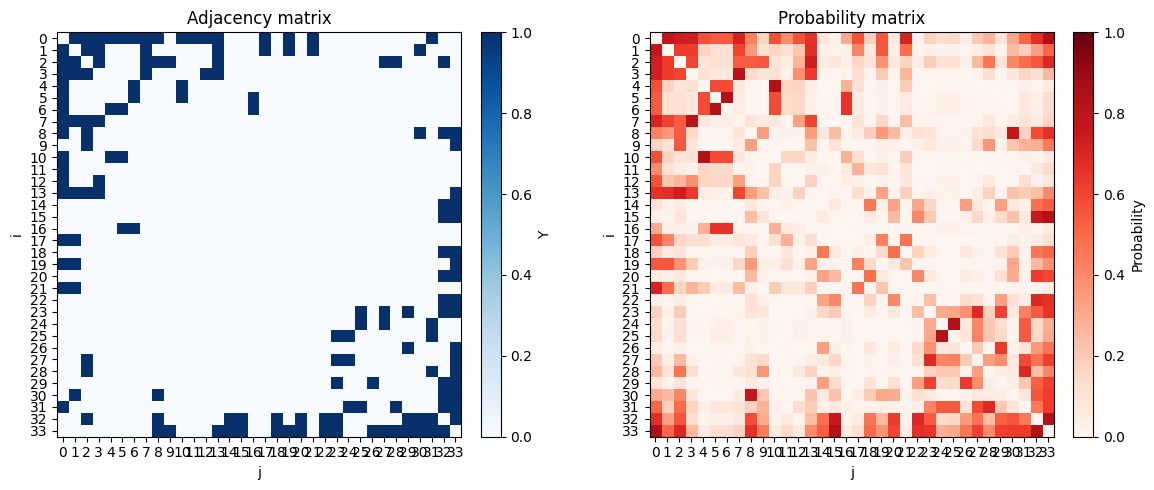

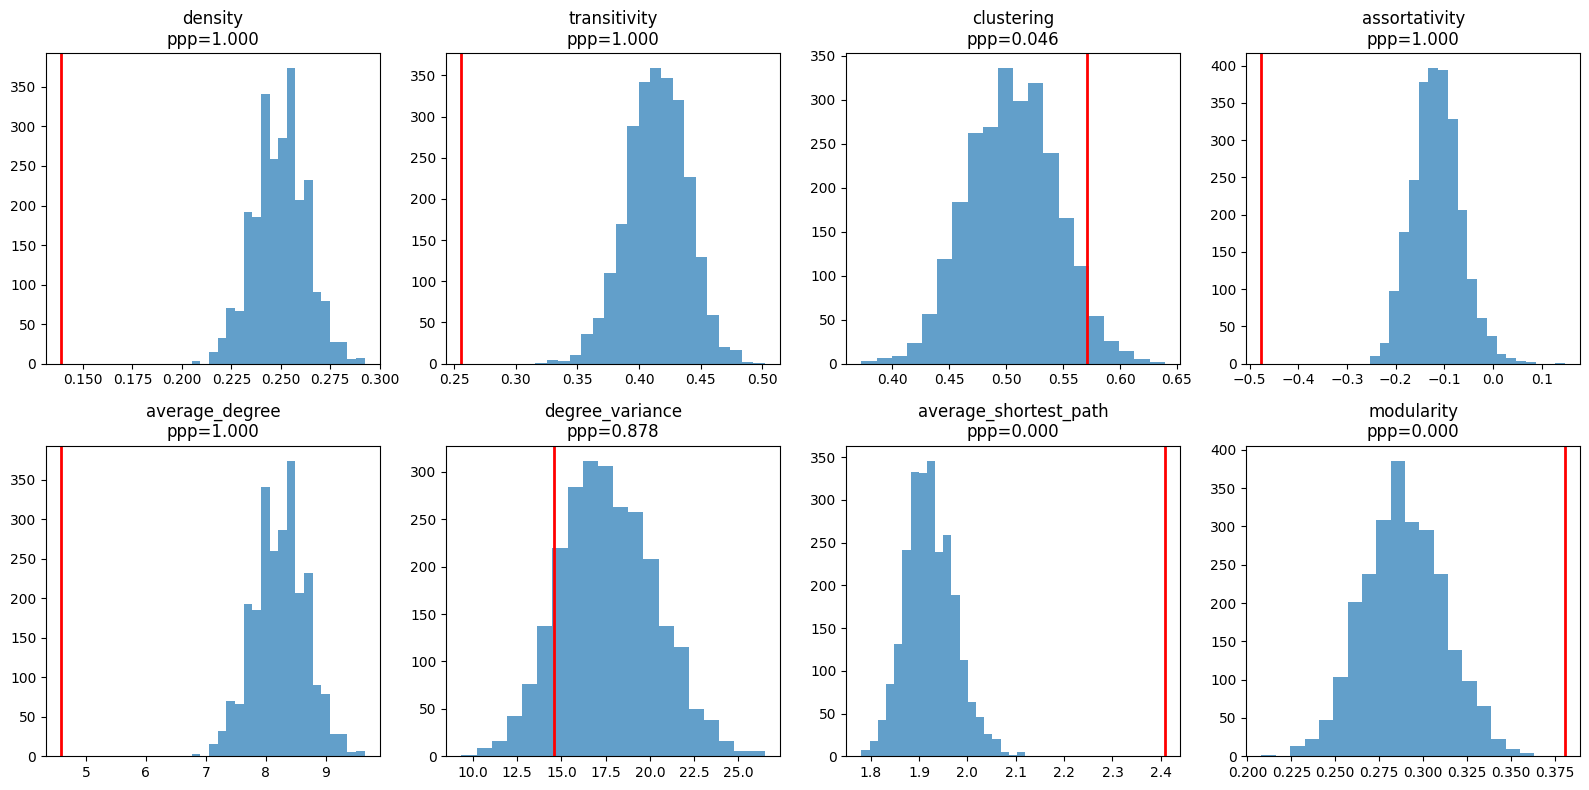

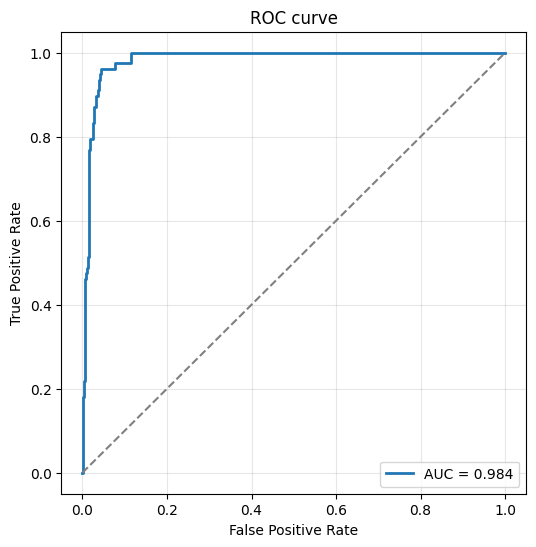

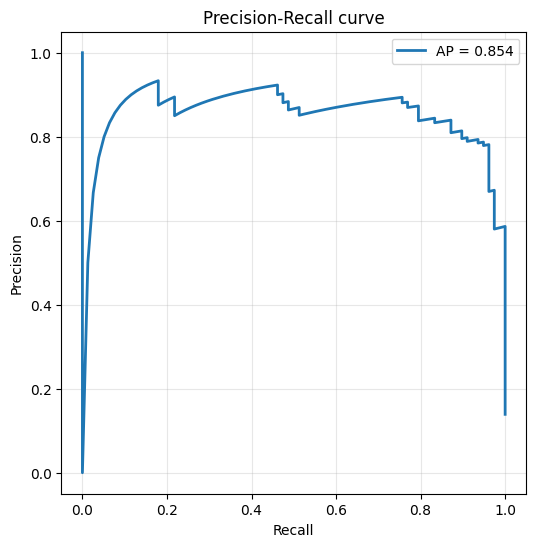

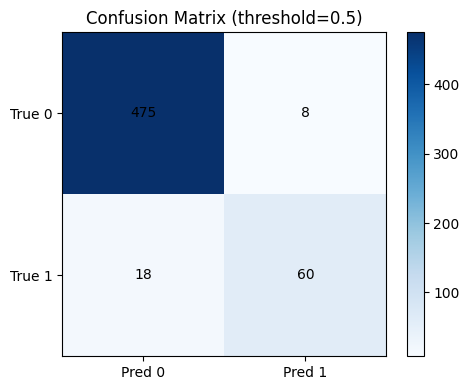

MAP:  30%|███       | 303/1000 [00:01<00:03, 207.46it/s, logpost=-79.1796, loglik=-79.1796, logprior=0.0000, ||grad||=0.0099, patience=49]


{'mean_auc': 0.9645494143045165, 'std_auc': 0.015214266897347284, 'min_auc': np.float64(0.9448329448329449), 'max_auc': np.float64(0.9854227405247813), 'n_folds': 5}


In [16]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [30]:
with open("Karate_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:   1%|          | 170/25000 [00:02<04:58, 83.20it/s, logpost=-203.5987, loglik=-202.9685, logprior=-0.6302, ||grad||=0.0138, patience=100] 


[STOP] Early stopping at iter 169 (no improvement in 101 steps)

Best log-posterior: -203.5987


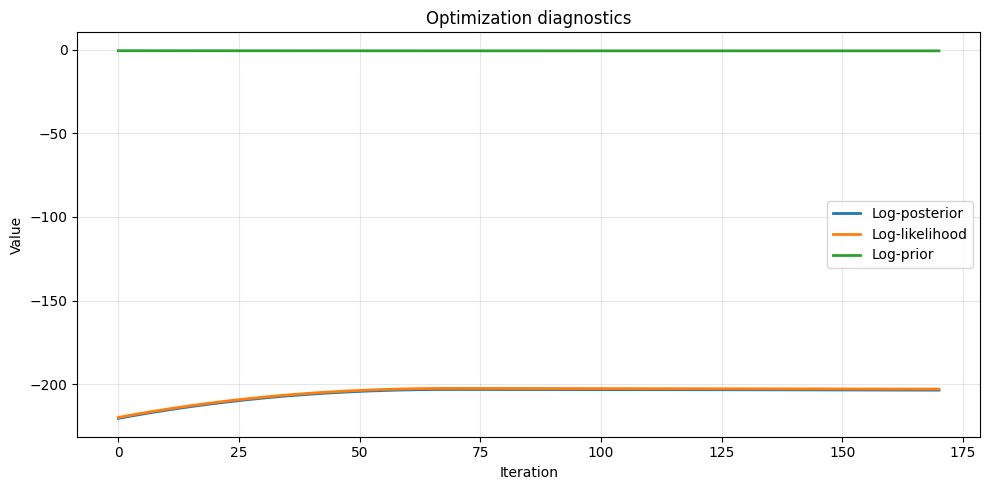

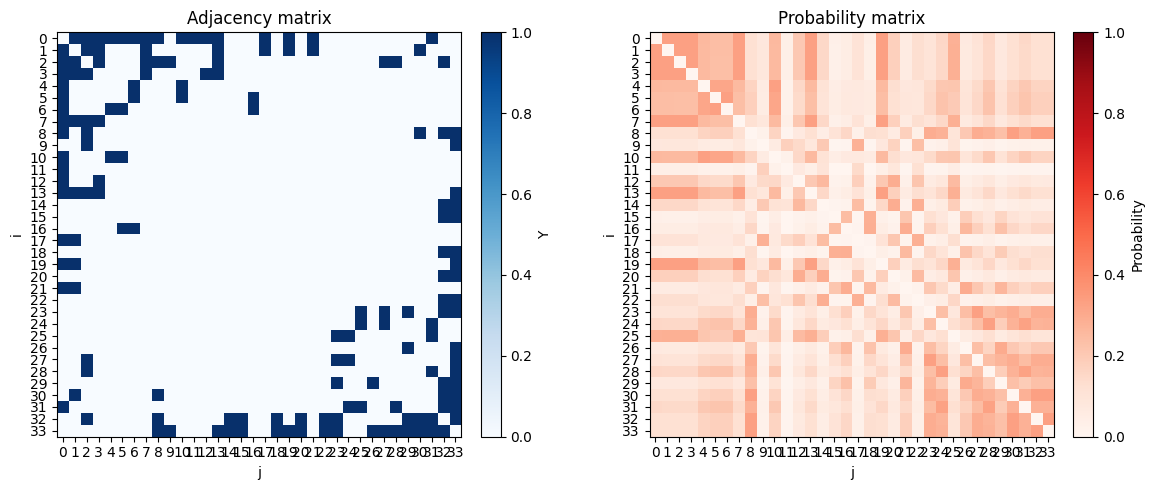

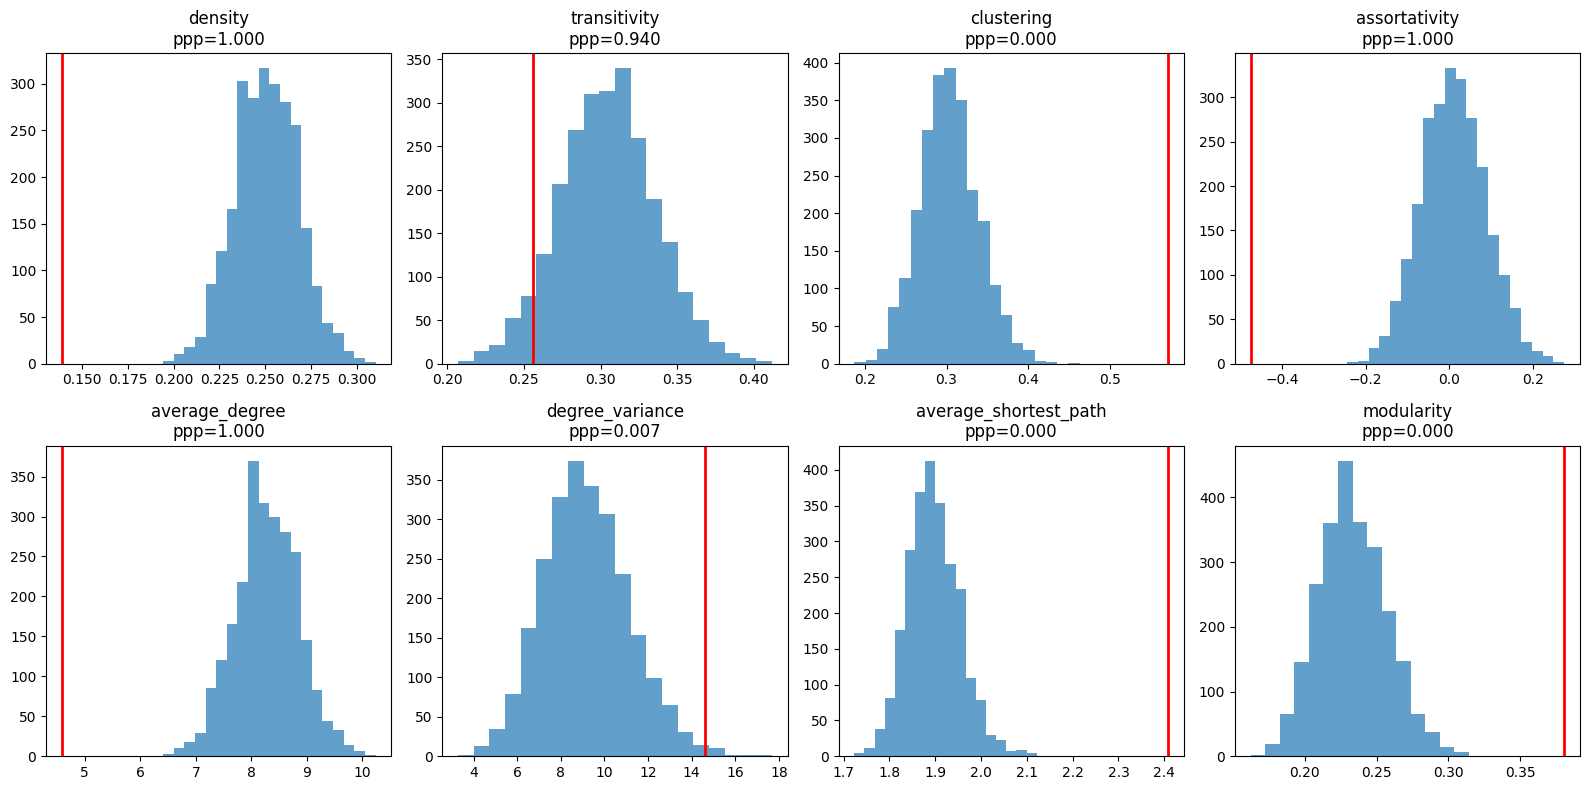

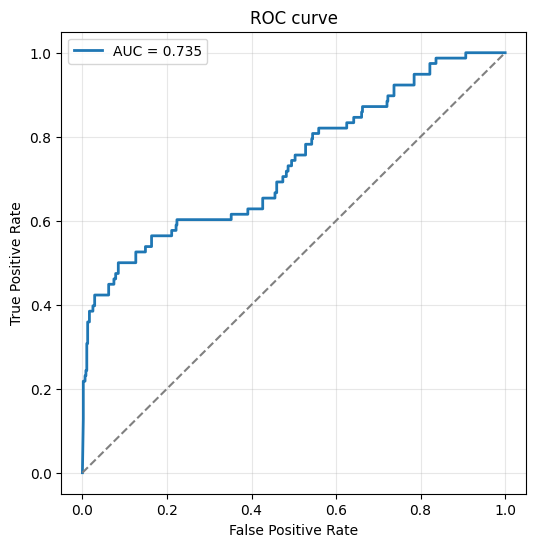

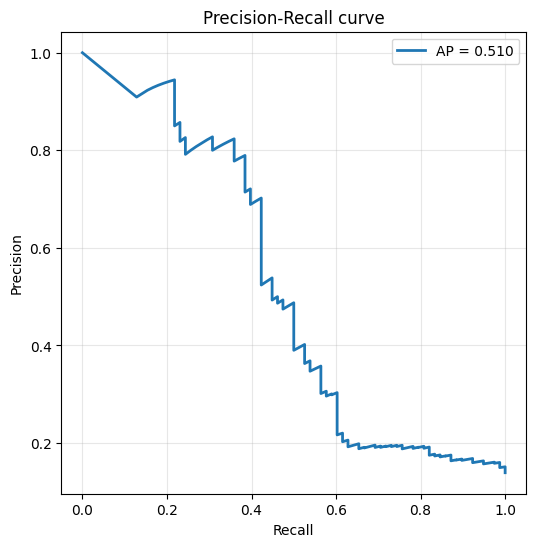

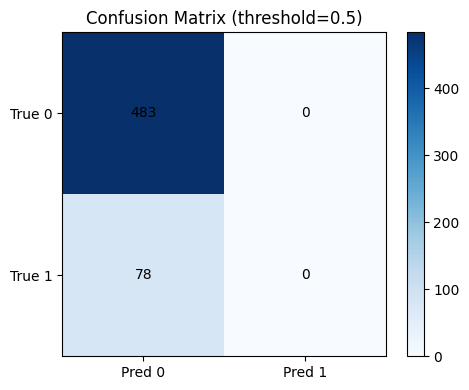

MAP:   5%|▌         | 51/1000 [00:01<00:19, 47.95it/s, logpost=-163.0289, loglik=-162.4029, logprior=-0.6260, ||grad||=0.0138, patience=49]


{'mean_auc': 0.7335472588635854, 'std_auc': 0.050593618989988584, 'min_auc': np.float64(0.6676384839650145), 'max_auc': np.float64(0.7902097902097901), 'n_folds': 5}


In [31]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  28%|██▊       | 7010/25000 [00:24<01:02, 288.15it/s, logpost=-179.8634, loglik=-179.8634, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 7009 (no improvement in 101 steps)

Best log-posterior: -179.8634


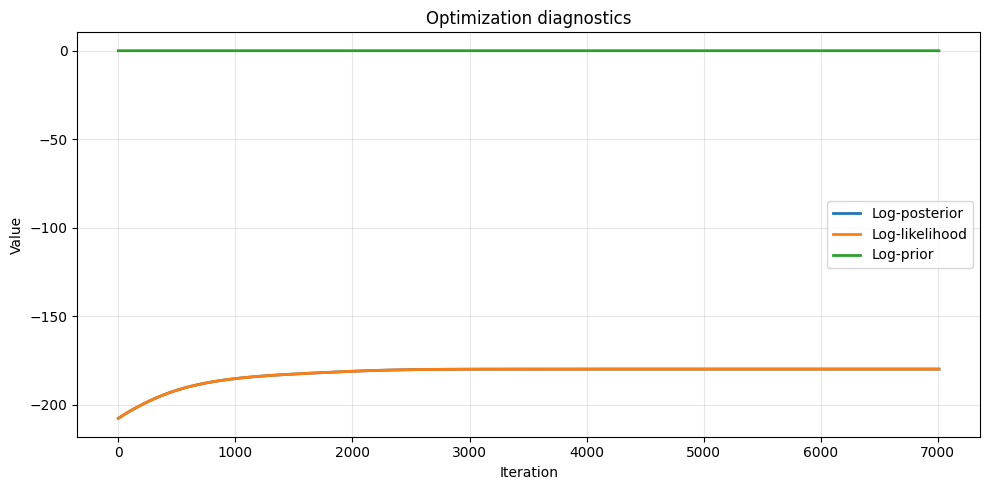

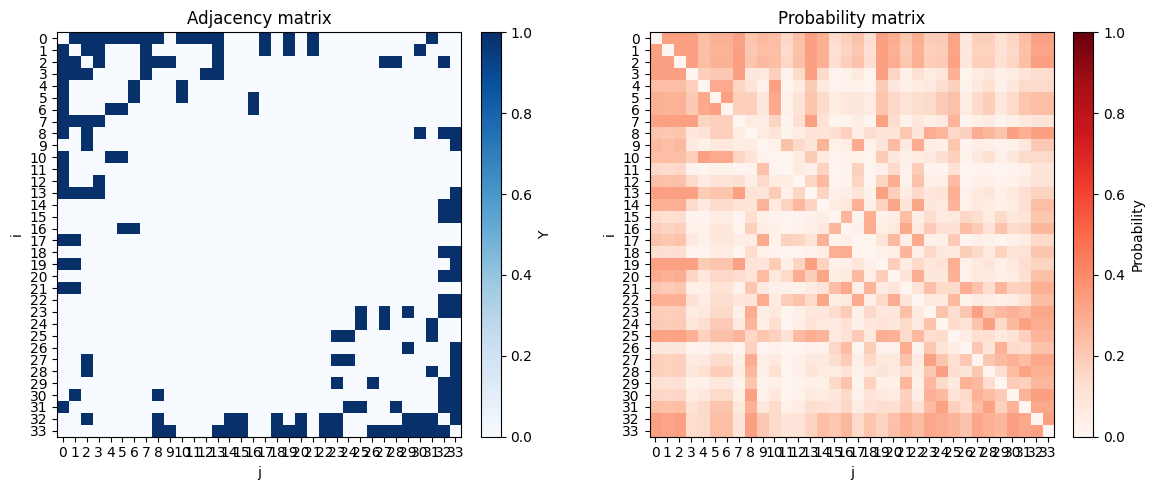

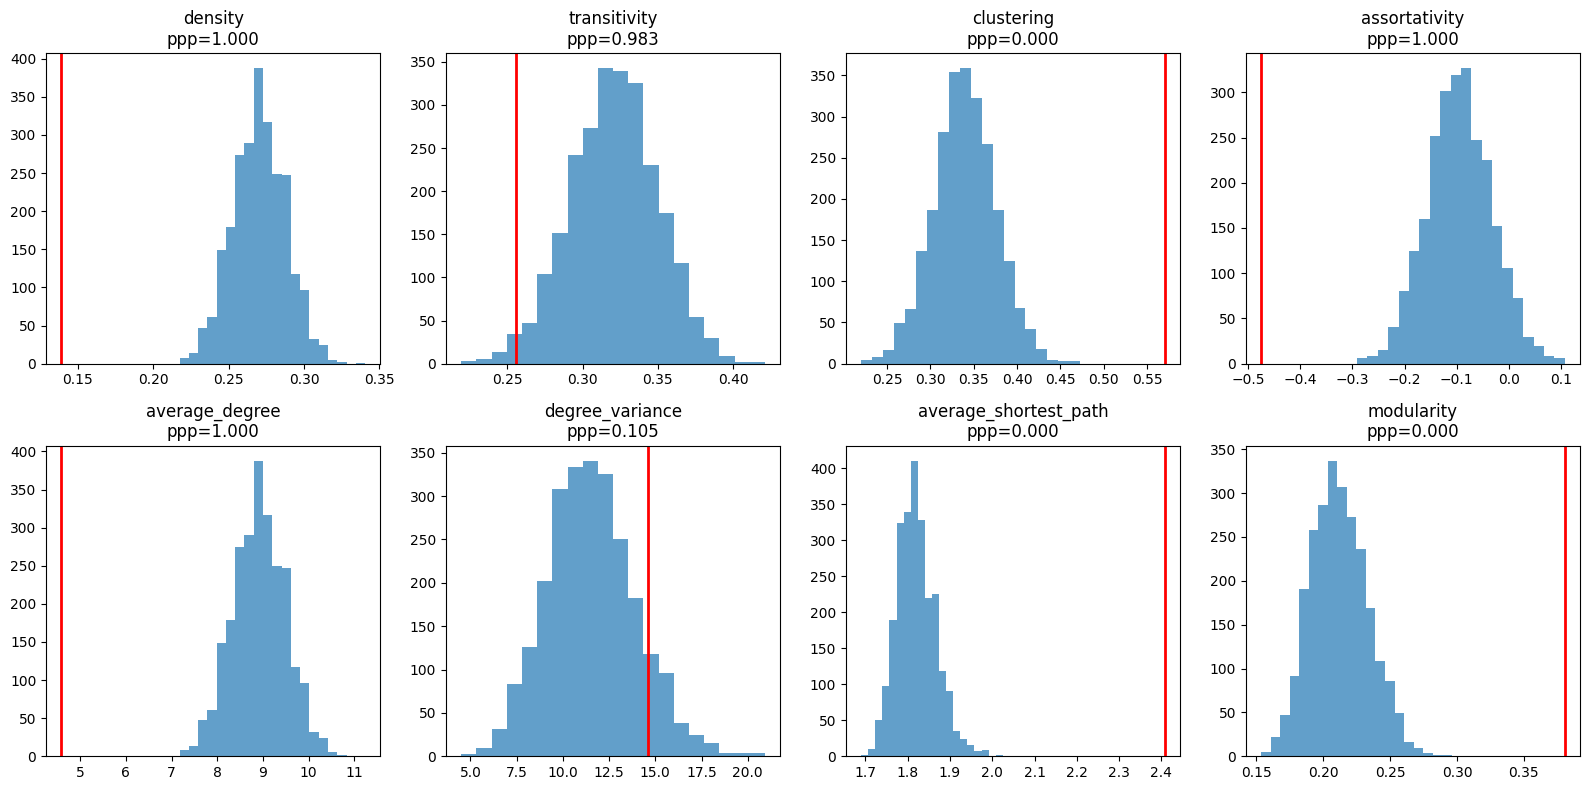

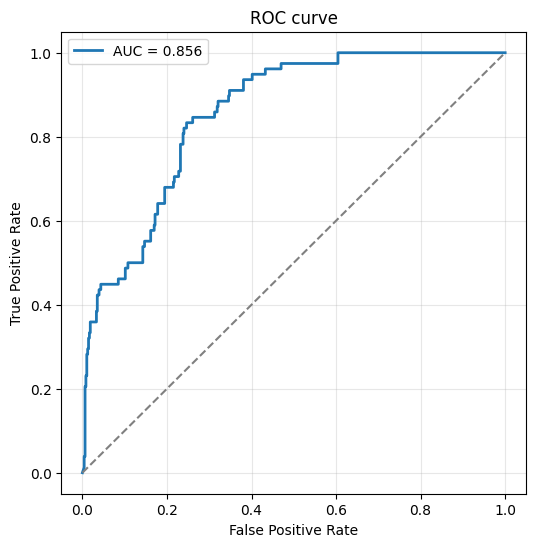

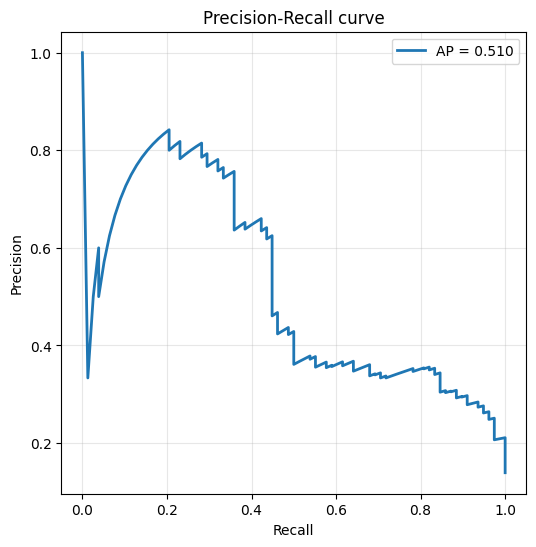

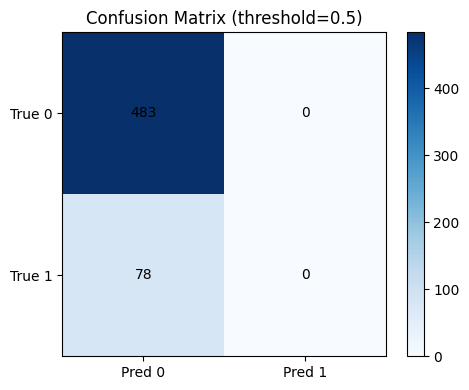

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 205.27it/s, logpost=-144.7849, loglik=-144.7849, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.7955887202366794, 'std_auc': 0.028253235137759514, 'min_auc': np.float64(0.7531818181818182), 'max_auc': np.float64(0.8329166666666666), 'n_folds': 5}


In [32]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [20]:
with open("Karate_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

Multi_start (1)


MAP:   1%|          | 256/25000 [00:02<03:56, 104.75it/s, logpost=-134.9576, loglik=-134.1104, logprior=-0.8471, ||grad||=0.0138, patience=100]


[STOP] Early stopping at iter 255 (no improvement in 101 steps)

Best log-posterior: -134.9576


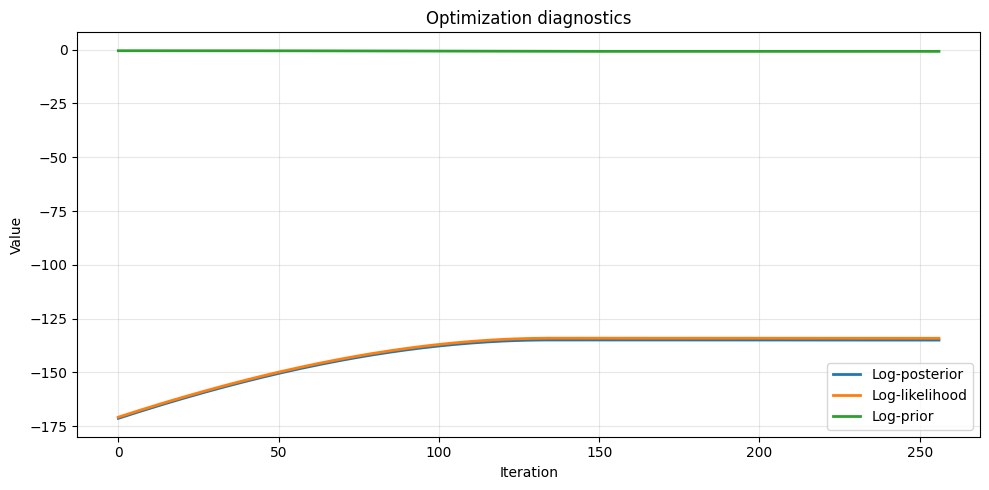

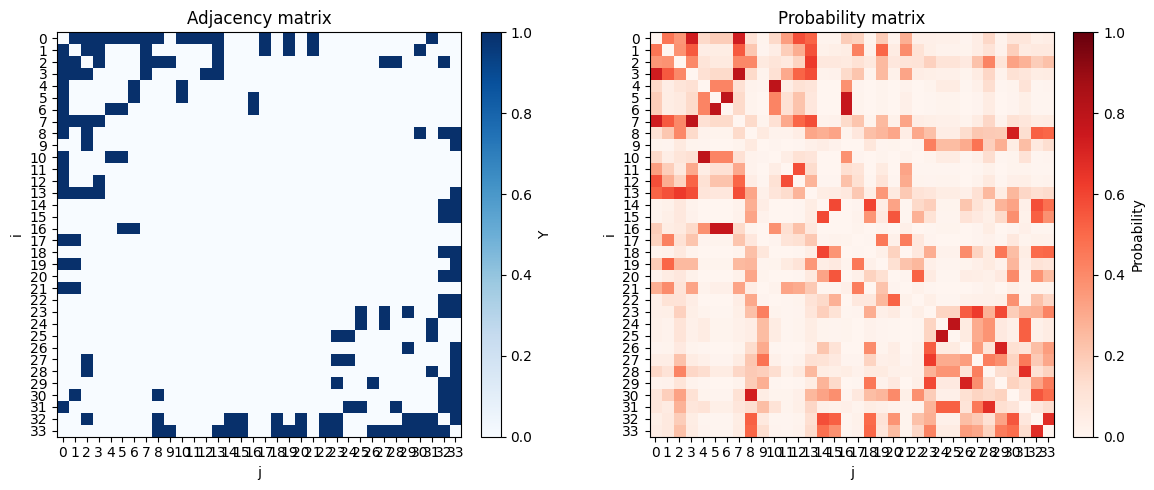

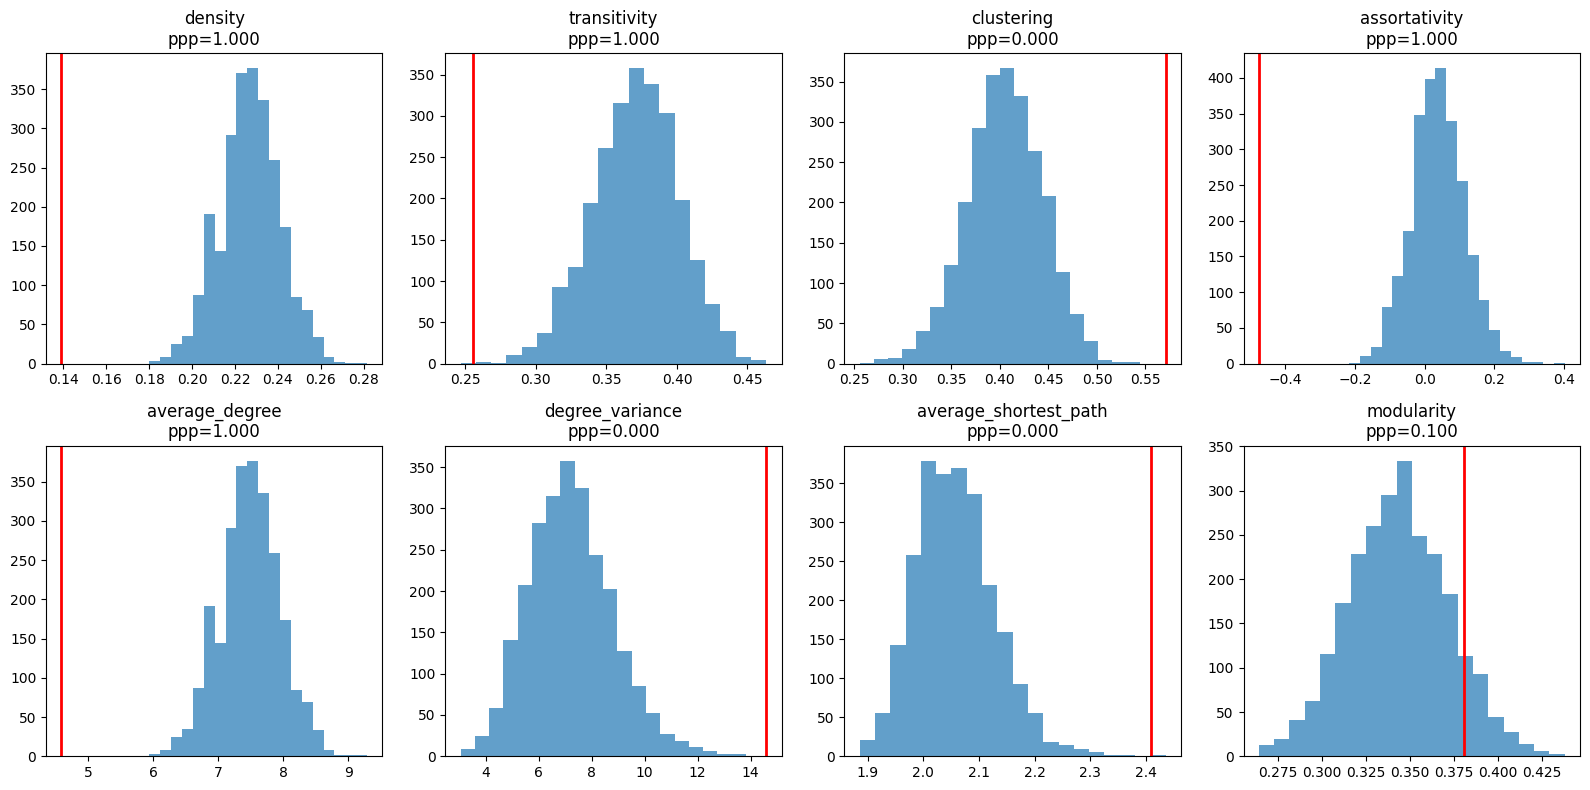

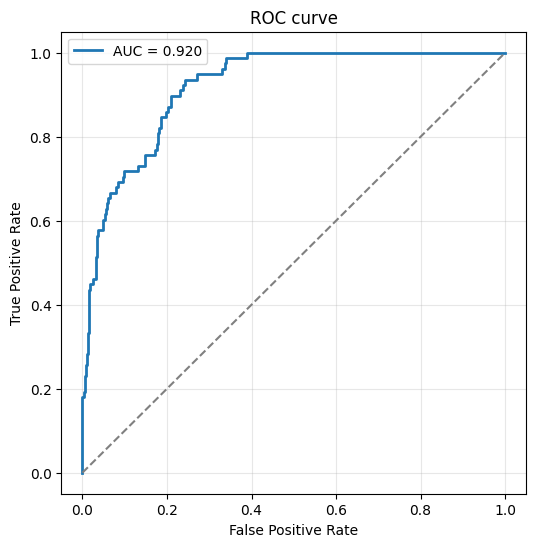

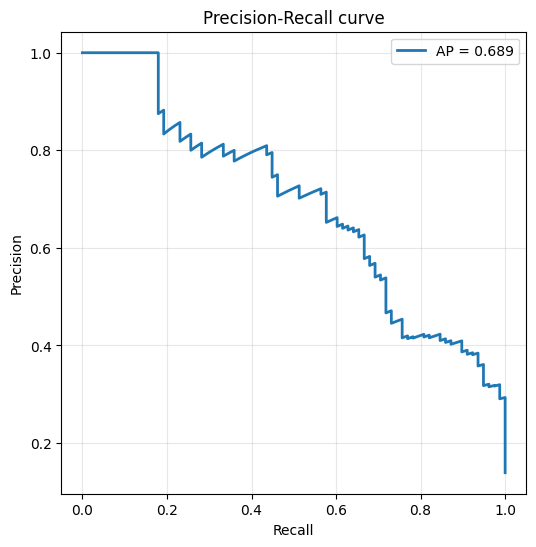

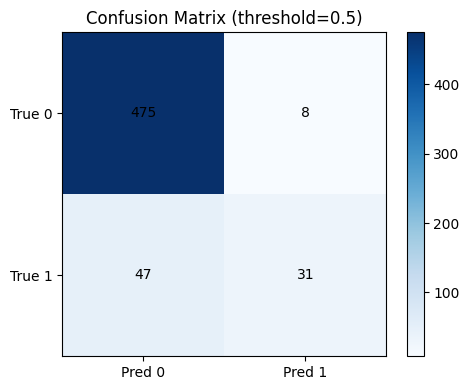

MAP:   5%|▌         | 50/1000 [00:00<00:18, 50.52it/s, logpost=-109.2567, loglik=-108.4018, logprior=-0.8549, ||grad||=0.0138, patience=49]


{'mean_auc': 0.9189999852754955, 'std_auc': 0.0169497282069037, 'min_auc': np.float64(0.8899416909620991), 'max_auc': np.float64(0.94), 'n_folds': 5}


In [21]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  12%|█▏        | 3002/25000 [00:08<01:05, 334.03it/s, logpost=-107.9047, loglik=-107.9047, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 3001 (no improvement in 101 steps)

Best log-posterior: -107.9047


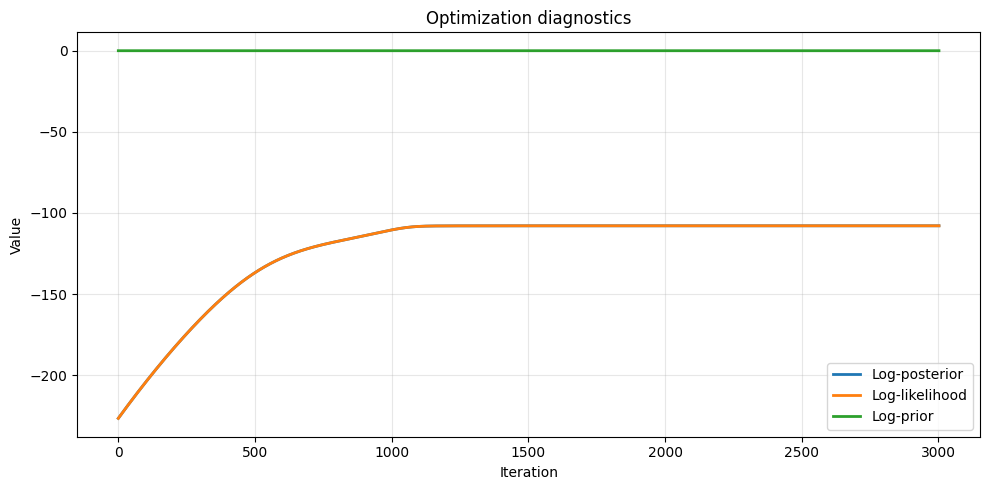

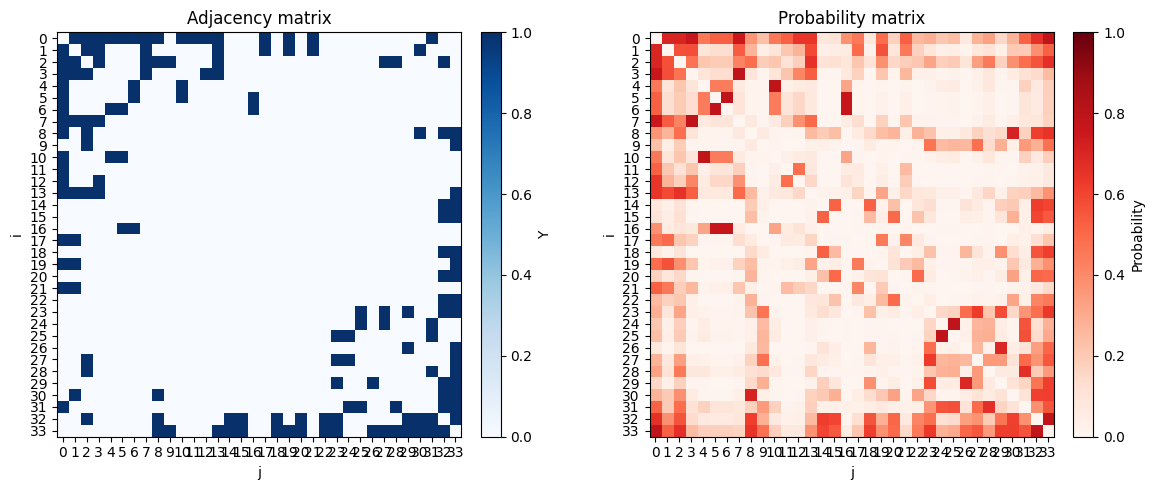

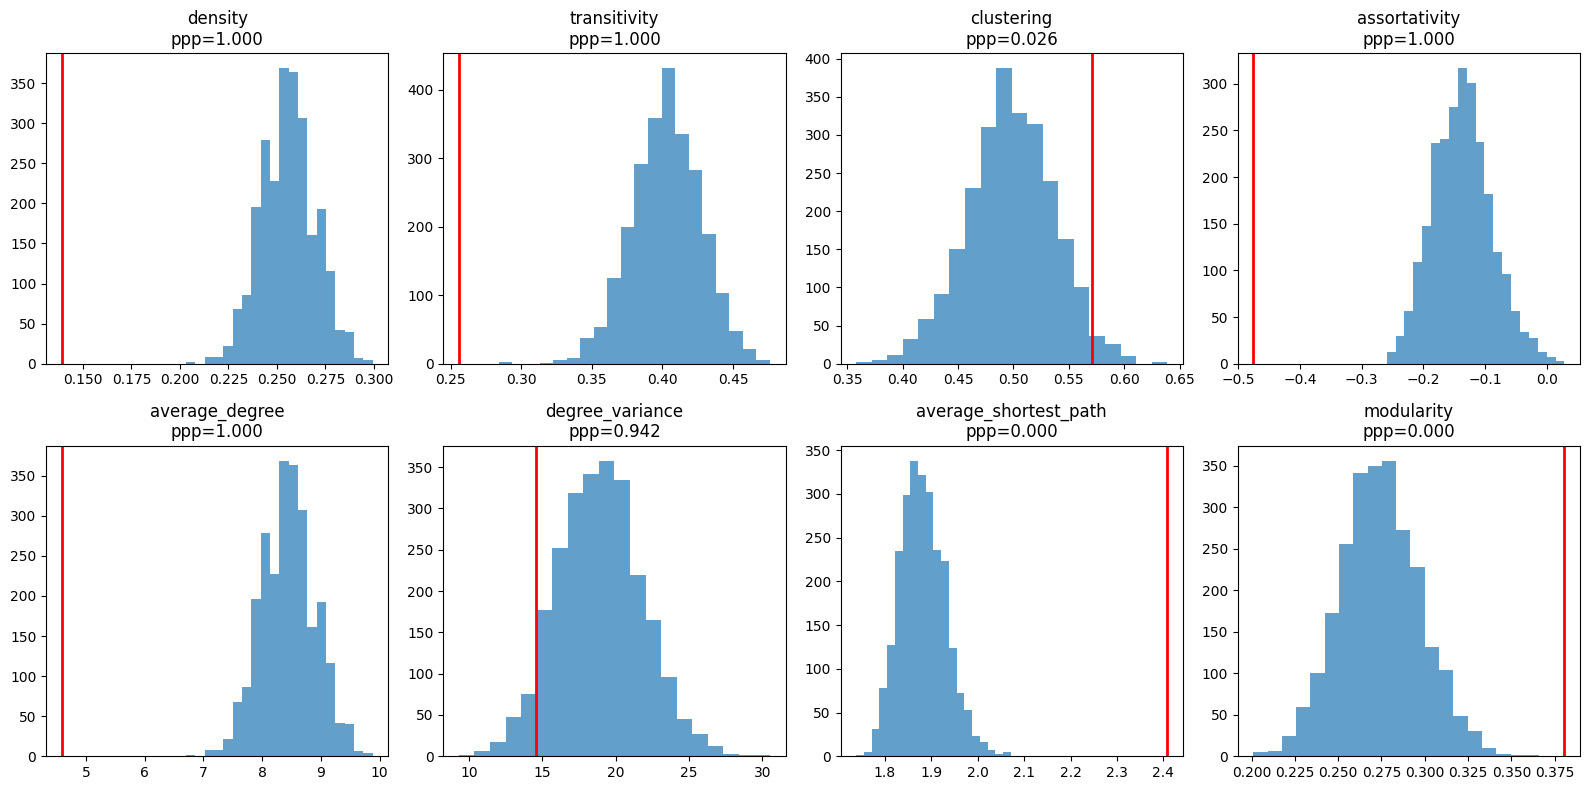

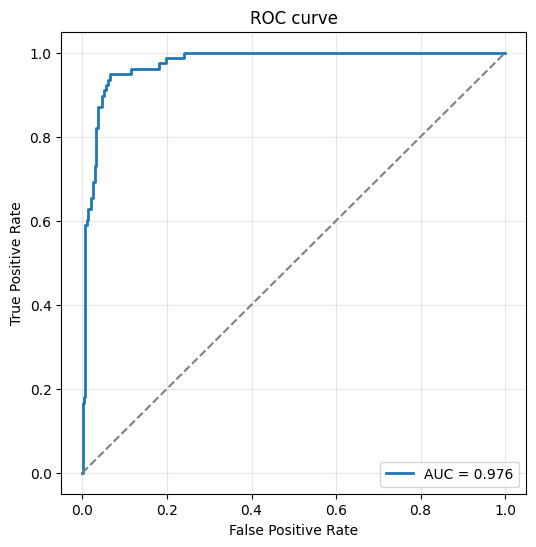

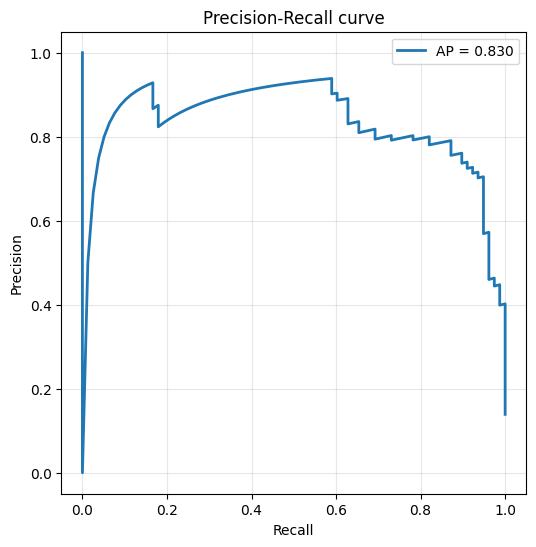

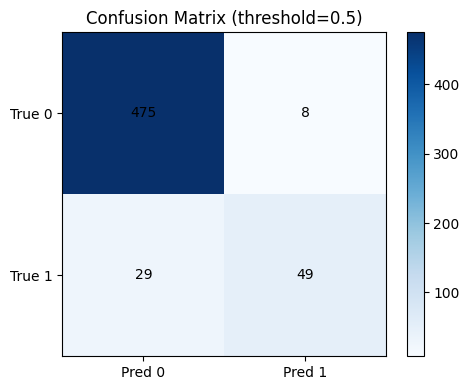

MAP:  65%|██████▌   | 651/1000 [00:02<00:01, 246.02it/s, logpost=-86.7038, loglik=-86.7038, logprior=0.0000, ||grad||=0.0090, patience=49]


{'mean_auc': 0.9496286094857525, 'std_auc': 0.014513741908072718, 'min_auc': np.float64(0.9324009324009325), 'max_auc': np.float64(0.9752186588921282), 'n_folds': 5}


In [22]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Karate_H2_p.pkl")

## Results

### Visualization of latent spaces 

$\mathbb{R}^1$

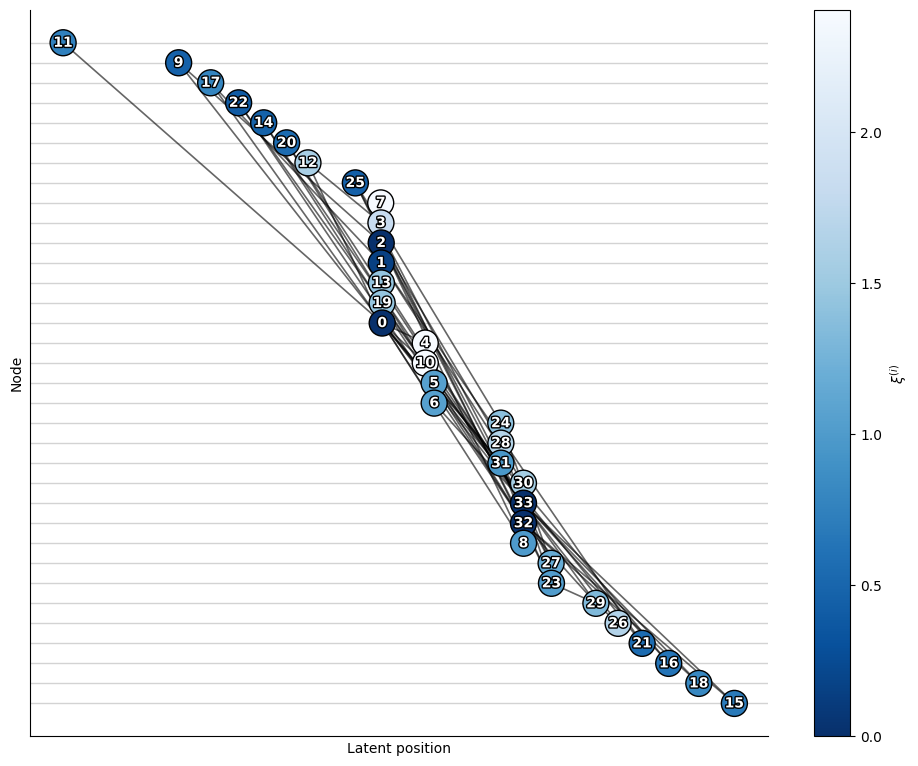

In [23]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Karate_R1_p.pkl", "rb") as f:
    results = pickle.load(f)
z = np.asarray(results["latent_params"]["Z"]).ravel()
xi = np.asarray(results["latent_params"]["xi"]).ravel()
Y = np.asarray(results["Y"])
n = len(z)
perm = np.argsort(z)
z = z[perm]
xi = xi[perm]
Y = Y[np.ix_(perm, perm)]
labels = perm
y = np.arange(n)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
cmap = plt.cm.Blues_r
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n):
    ax.axhline(y=i, color="lightgray", lw=1, zorder=0)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([z[i], z[j]], [y[i], y[j]], color="black", lw=1.2, alpha=0.6, zorder=1 )

sc = ax.scatter(z, y, c=xi, cmap=cmap, norm=norm, s=350, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(z[i], y[i], str(labels[i]), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Latent position")
ax.set_ylabel("Node")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
ax.set_xticks([])
ax.set_yticks([])
plt.show()

$\mathbb{R}^2$

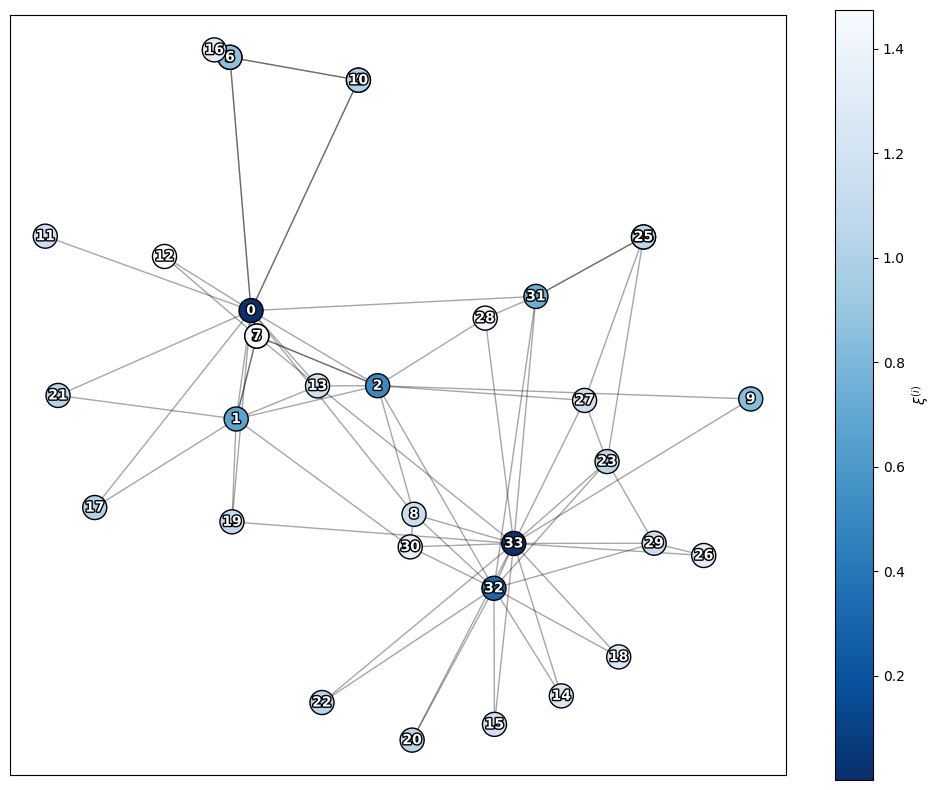

In [24]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Karate_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)
Z = np.asarray(results_R2_p['latent_params']['Z'])
xi = np.asarray(results_R2_p['latent_params']['xi']).ravel()
Y = np.asarray(results_R2_p['Y'])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(x[i], y[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_aspect("equal")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

$\mathbb{R}^3$

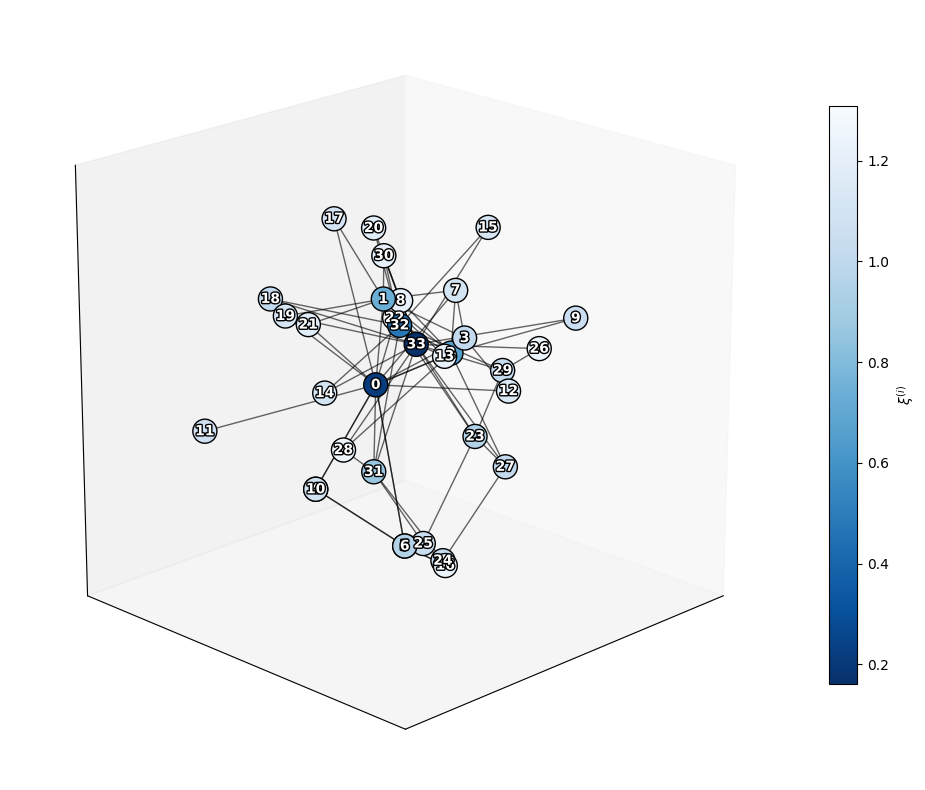

In [25]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe
with open("Karate_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)
Z = np.asarray(results_R3_p["latent_params"]["Z"])
xi = np.asarray(results_R3_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_R3_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], color="black", alpha=0.6, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, z, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolors="black", depthshade=True, zorder=3, alpha=1.0)
for i in range(n):
    txt = ax.text(x[i], y[i], z[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

$\mathbb{S}^1$

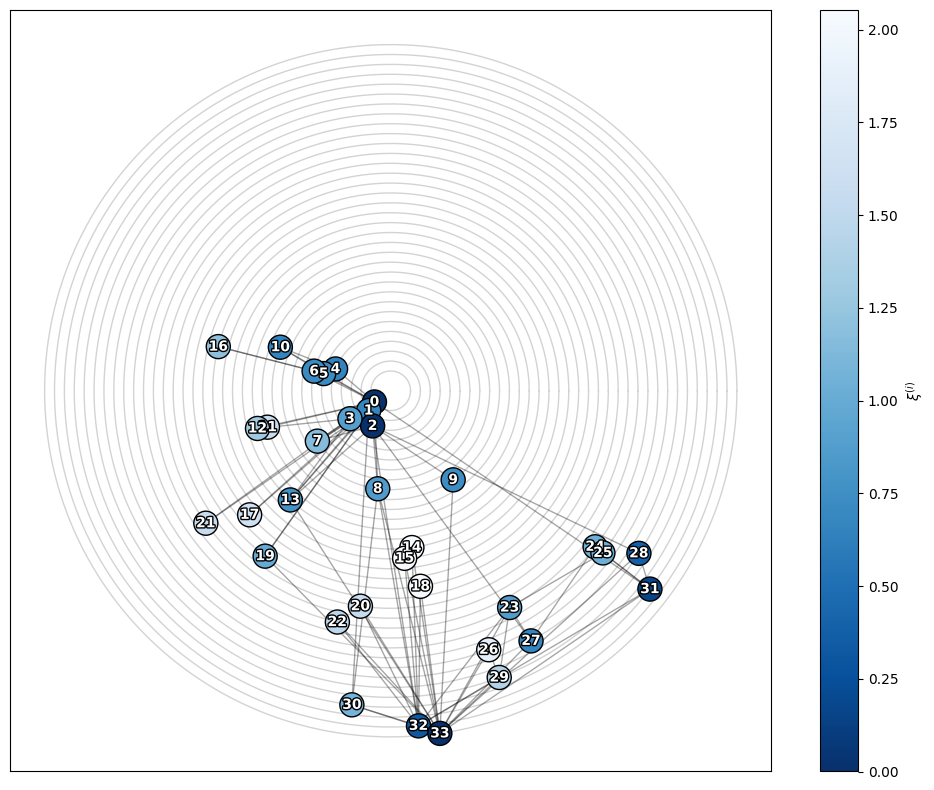

In [26]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Karate_S1_p.pkl", "rb") as f:
    results_S1_p = pickle.load(f)
Z  = np.asarray(results_S1_p["latent_params"]["Z"])
xi = np.asarray(results_S1_p["latent_params"]["xi"]).ravel()
Y  = np.asarray(results_S1_p["Y"])
n = len(xi)
theta = np.arctan2(Z[:,1], Z[:,0])
r0 = 1.0
dr = 0.5
radii = r0 + dr*np.arange(n)
x = radii*np.cos(theta)
y = radii*np.sin(theta)
fig, ax = plt.subplots(figsize=(10,8))
tt = np.linspace(0, 2*np.pi, 500)
for r in radii:
    ax.plot(r*np.cos(tt), r*np.sin(tt), color="lightgray", lw=1, zorder=0)
for i in range(n):
    for j in range(i+1,n):
        if Y[i,j] > 0:
            ax.plot([x[i],x[j]], [y[i],y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(x[i], y[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center", zorder=4)
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

$\mathbb{S}^2$

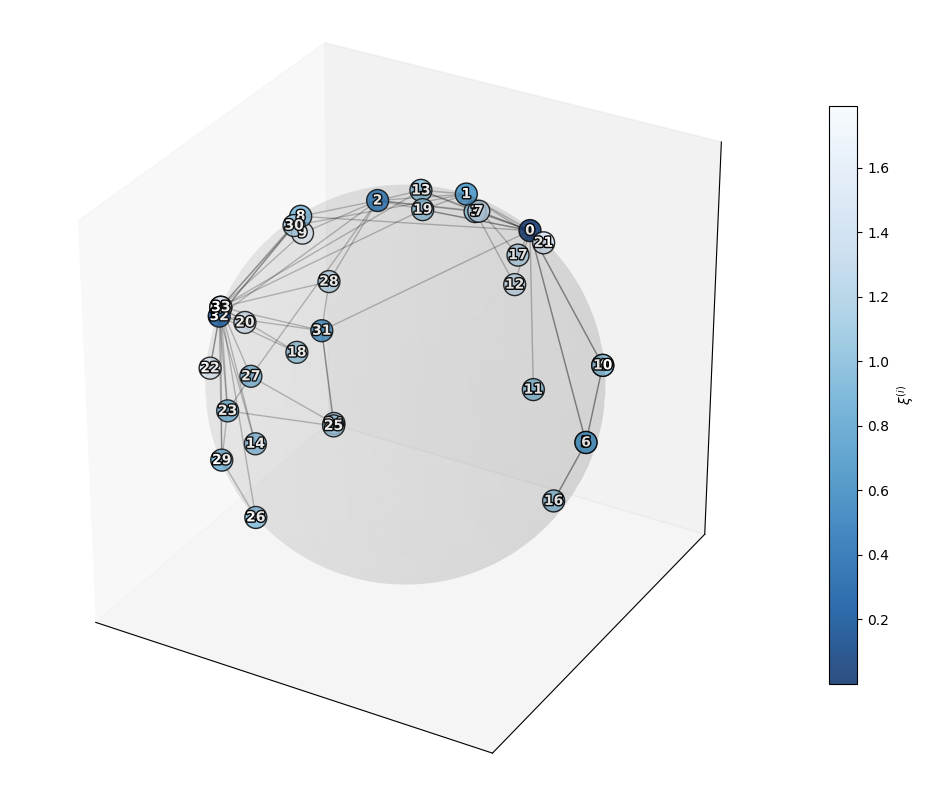

In [4]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe

with open("Karate_S2_p.pkl", "rb") as f:
    results_S2_p = pickle.load(f)
Z = np.asarray(results_S2_p["latent_params"]["Z"])
xi = np.asarray(results_S2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_S2_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
R = (x[0]**2 + y[0]**2  + z[0]**2)**0.5
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = R*np.outer(np.cos(u), np.sin(v))
ys = R*np.outer(np.sin(u), np.sin(v))
zs = R*np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xs, ys, zs, alpha=0.08, color="gray", linewidth=0, zorder=0)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], color="black", alpha=0.25, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, z, c=xi, cmap="Blues_r", norm=norm, s=250, edgecolors="black", depthshade=True, zorder=3, alpha=0.85)
for i in range(n):
    txt = ax.text(x[i], y[i], z[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1,1,1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)
plt.tight_layout()
plt.show()

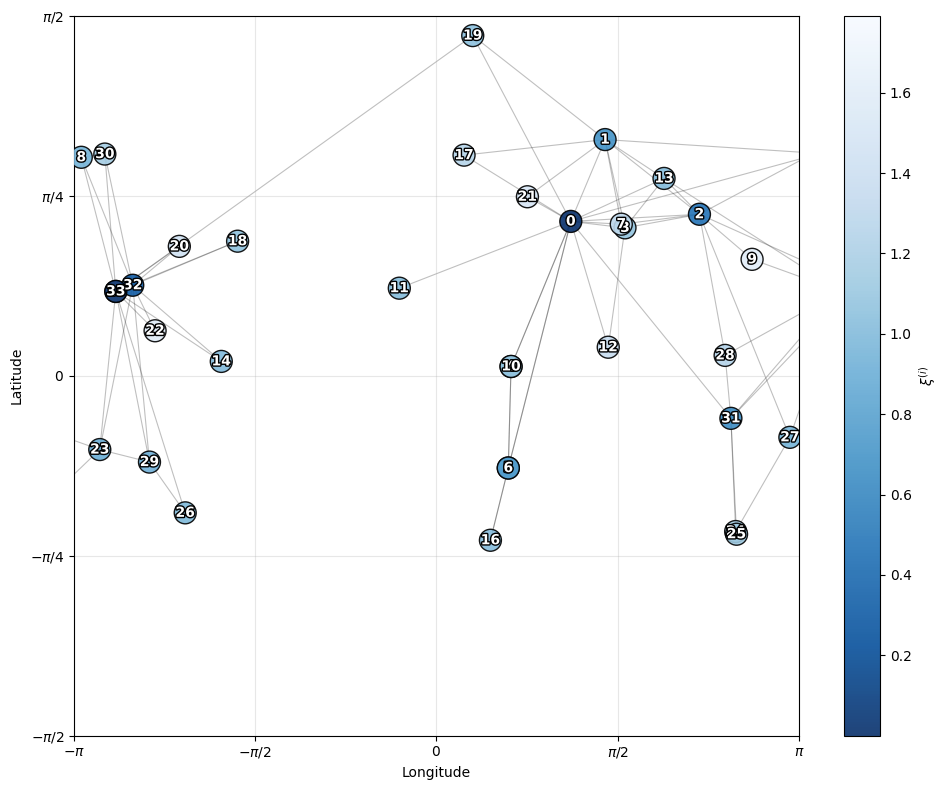

In [39]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe

with open("Karate_S2_p.pkl", "rb") as f:
    results_S2_p = pickle.load(f)
Z = np.asarray(results_S2_p["latent_params"]["Z"])
xi = np.asarray(results_S2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_S2_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
R = np.linalg.norm(Z[0])
theta = np.arctan2(y, x)                  # longitude
phi = np.arccos(np.clip(z / R, -1, 1))    # colatitude
latitude = np.pi/2 - phi # latitude
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            dtheta = theta[j] - theta[i]
            if dtheta > np.pi:
                dtheta -= 2*np.pi
            elif dtheta < -np.pi:
                dtheta += 2*np.pi
            ax.plot([theta[i], theta[i] + dtheta], [latitude[i], latitude[j]], color="black",alpha=0.25,lw=0.8,zorder=1)

norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(theta, latitude,c=xi,cmap="Blues_r",norm=norm,s=250,edgecolors="black",alpha=0.9,zorder=3)
for i in range(n):
    txt = ax.text(theta[i],latitude[i],str(i),color="white",fontsize=10,fontweight="bold",ha="center",va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi/2, np.pi/2)
ax.set_xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax.set_xticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax.set_yticks([-np.pi/2,-np.pi/4,0,np.pi/4,np.pi/2])
ax.set_yticklabels([r"$-\pi/2$",r"$-\pi/4$",r"$0$",r"$\pi/4$",r"$\pi/2$"])
ax.set_xlabel(r"Longitude")
ax.set_ylabel(r"Latitude")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

$\mathbb{H}^1$

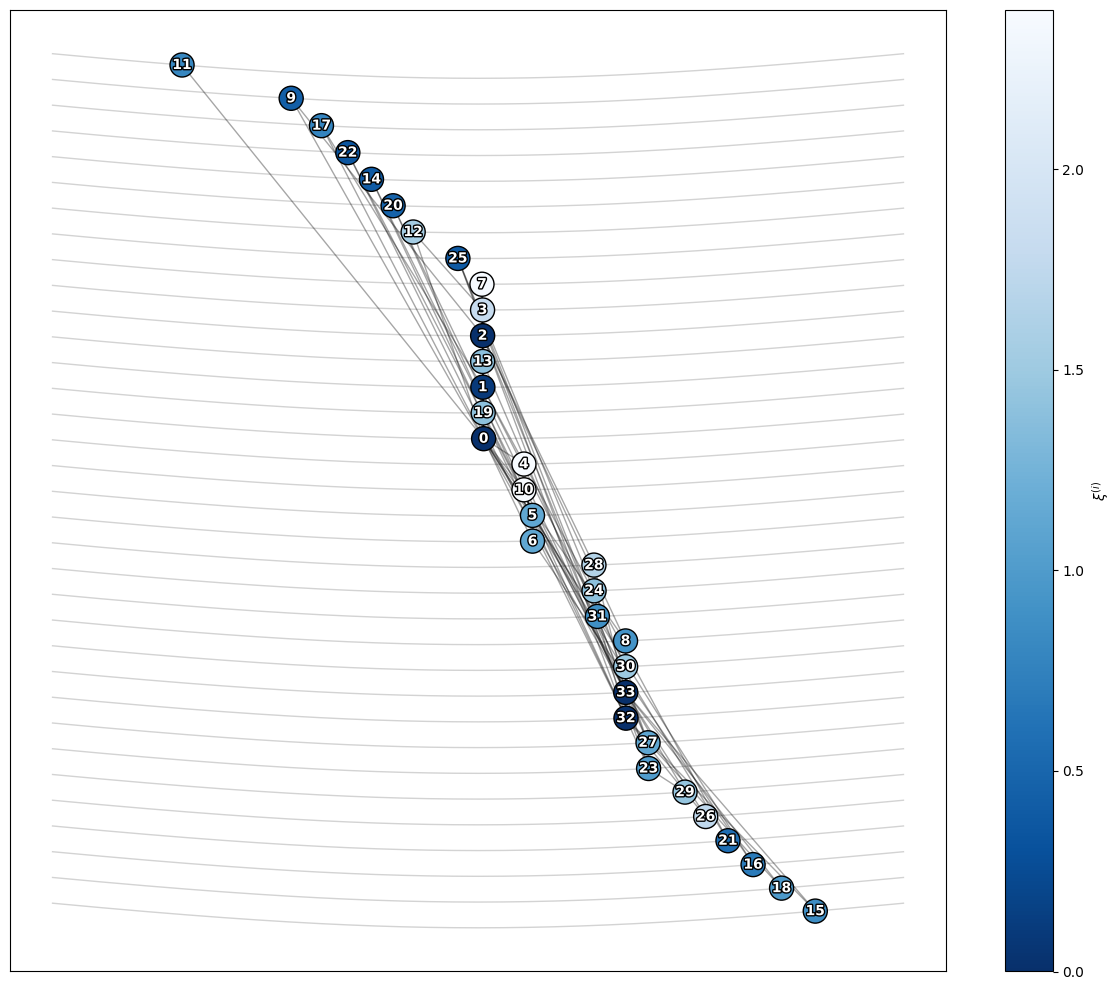

In [35]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Karate_H1_p.pkl", "rb") as f:
    results_H1_p = pickle.load(f)
diam = 10.0
R = diam / np.pi
Z = np.asarray(results_H1_p["latent_params"]["Z"])
xi = np.asarray(results_H1_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H1_p["Y"])
n = len(xi)
x0 = Z[:, 0]
x1 = Z[:, 1]
t_nodes = np.arcsinh(x0 / R)
perm = np.argsort(t_nodes)
t_nodes = t_nodes[perm]
xi = xi[perm]
Y = Y[np.ix_(perm, perm)]
labels = perm
lim_range_t = max(np.max(np.abs(t_nodes))*1.15, np.pi/3)
t = np.linspace(-lim_range_t, lim_range_t, 1000)
base_x = R*np.sinh(t)
base_y = R*np.cosh(t)
spacing = 2.0
node_x = np.zeros(n)
node_y = np.zeros(n)
fig, ax = plt.subplots(figsize=(12,10))
for i in range(n):
    offset = -i*spacing
    ax.plot(base_x, base_y + offset, color="lightgray", lw=1.0, zorder=0)
    node_x[i] = R*np.sinh(t_nodes[i])
    node_y[i] = R*np.cosh(t_nodes[i]) + offset
for i in range(n):
    for j in range(i+1, n):
        if Y[i,j] > 0:
            ax.plot([node_x[i], node_x[j]], [node_y[i], node_y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(node_x, node_y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(node_x[i], node_y[i], str(labels[i]), color="white", fontsize=10, fontweight="bold",ha="center",va="center",zorder=4)
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

$\mathbb{H}^2$

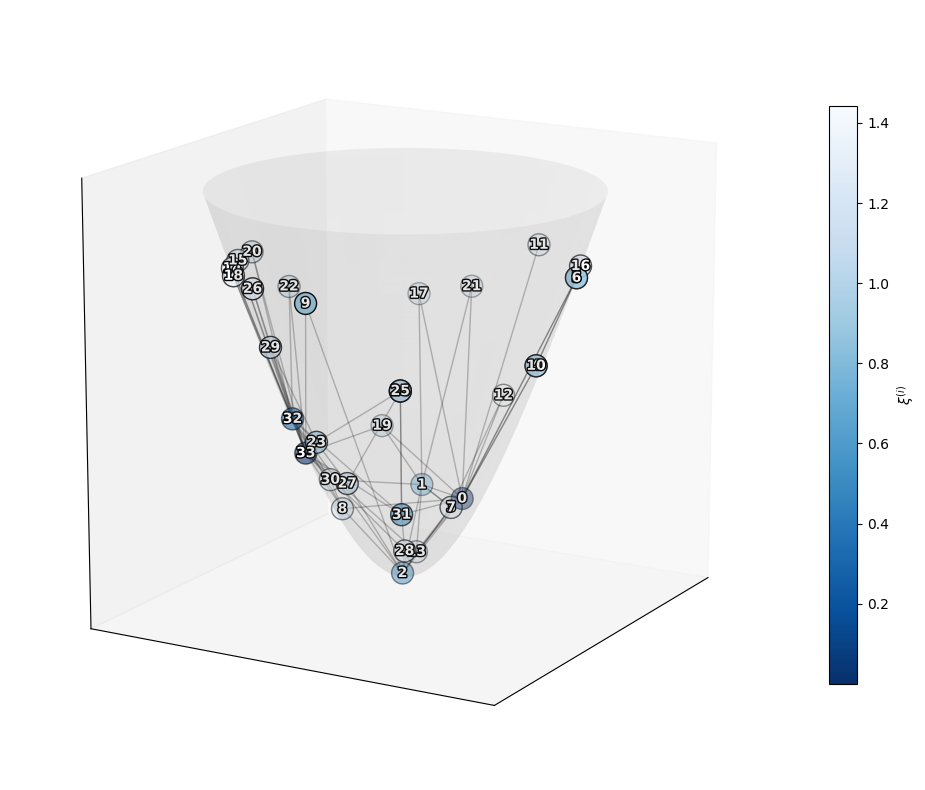

In [29]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe
with open("Karate_H2_p.pkl", "rb") as f:
    results_H2_p = pickle.load(f)
Z = np.asarray(results_H2_p["latent_params"]["Z"])
xi = np.asarray(results_H2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H2_p["Y"])
n = len(xi)
x0 = Z[:, 0]
x1 = Z[:, 1]
x2 = Z[:, 2]
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
rmax = np.max(np.sqrt(x1**2 + x2**2)) * 0.75
r = np.linspace(0, rmax, 100)
theta = np.linspace(0, 2*np.pi, 150)
R, Theta = np.meshgrid(r, theta)
X1 = R * np.cos(Theta)
X2 = R * np.sin(Theta)
X0 = np.sqrt((diam/np.pi)**2 + X1**2 + X2**2)
ax.plot_surface(X1, X2, X0, alpha=0.08, color="gray", linewidth=0, antialiased=True)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x0[i], x0[j]], [x1[i], x1[j]],  [x2[i], x2[j]], color="black", alpha=0.25, lw=1.0)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x0, x1, x2, c=xi, cmap="Blues_r", norm=norm, s=250, edgecolors="black", depthshade=True)
for i in range(n):
    txt = ax.text(x0[i], x1[i], x2[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1,1,1])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.view_init(elev=15, azim=30)
plt.tight_layout()
plt.show()

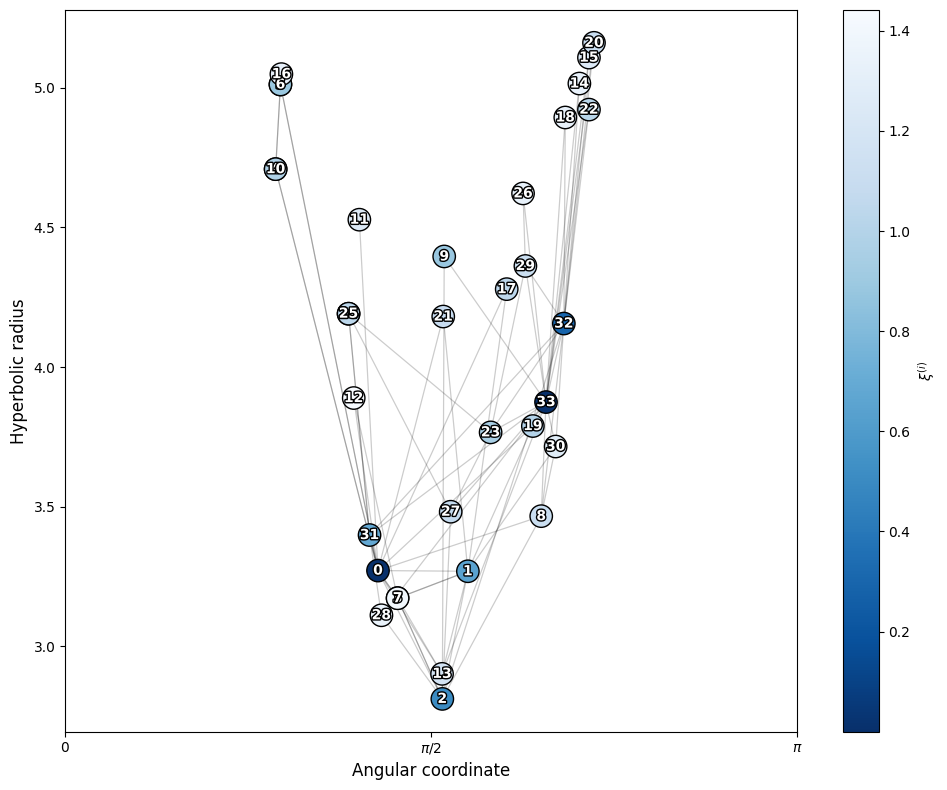

In [40]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Karate_H2_p.pkl", "rb") as f:
    results_H2_p = pickle.load(f)
Z  = np.asarray(results_H2_p["latent_params"]["Z"])
xi = np.asarray(results_H2_p["latent_params"]["xi"]).ravel()
Y  = np.asarray(results_H2_p["Y"])
n = len(xi)
x0 = Z[:,0]
x1 = Z[:,1]
x2 = Z[:,2]
rE = np.sqrt(x1**2 + x2**2)
theta = np.arctan2(x2, x1)
rho = R * np.arcsinh(rE / R)
fig, ax = plt.subplots(figsize=(10,8))
rho_max = rho.max()
for i in range(n):
    for j in range(i+1, n):
        if Y[i,j] == 0:
            continue
        dtheta = theta[j] - theta[i]
        if np.abs(dtheta) <= np.pi:
            ax.plot([theta[i], theta[j]],[rho[i], rho[j]],color="black",alpha=0.20,lw=0.9,zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(theta, rho, c=xi, cmap="Blues_r", norm=norm, s=260, edgecolors="black", linewidths=1.0, zorder=3)
for i in range(n):
    txt = ax.text(theta[i],rho[i],str(i),ha="center",va="center",fontsize=10,fontweight="bold",color="white",zorder=4)
    txt.set_path_effects([pe.withStroke(linewidth=2,foreground="black")])
cbar = plt.colorbar(sc)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_xlim(0, np.pi)
ax.set_xticks([0, np.pi/2,np.pi])
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$"])
ax.set_xlabel(r"Angular coordinate", fontsize=12)
ax.set_ylabel(r"Hyperbolic radius", fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

### Clustering

In [4]:

import pickle
import numpy as np


models = {
    ("Euclidean", 1, "Classical"): "Karate_R1_c.pkl",
    ("Euclidean", 1, "Weighted") : "Karate_R1_p.pkl",

    ("Euclidean", 2, "Classical"): "Karate_R2_c.pkl",
    ("Euclidean", 2, "Weighted") : "Karate_R2_p.pkl",

    ("Spherical", 1, "Classical"): "Karate_S1_c.pkl",
    ("Spherical", 1, "Weighted") : "Karate_S1_p.pkl",

    ("Spherical", 2, "Classical"): "Karate_S2_c.pkl",
    ("Spherical", 2, "Weighted") : "Karate_S2_p.pkl",

    ("Hyperbolic", 1, "Classical"): "Karate_H1_c.pkl",
    ("Hyperbolic", 1, "Weighted") : "Karate_H1_p.pkl",

    ("Hyperbolic", 2, "Classical"): "Karate_H2_c.pkl",
    ("Hyperbolic", 2, "Weighted") : "Karate_H2_p.pkl",
}

results = {}

for key, filename in models.items():

    with open(filename, "rb") as f:
        results[key] = pickle.load(f)

print(f"{len(results)} models loaded.")


12 models loaded.


In [5]:

import numpy as np
import pandas as pd
import networkx as nx
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score,
    accuracy_score
)


# Karate Club
G = nx.karate_club_graph()
# 0 = Mr. Hi
# 1 = Officer
y_true = np.array([0 if G.nodes[i]["club"] == "Mr. Hi" else 1 for i in G.nodes()])


def evaluate_model(P, random_state=123):
    P = 0.5 * (P + P.T)
    P = np.clip(P, 0, 1)
    np.fill_diagonal(P, 1.0)
    labels = SpectralClustering(
        n_clusters=2,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=random_state
    ).fit_predict(P)
    acc1 = accuracy_score(y_true, labels)
    acc2 = accuracy_score(y_true, 1 - labels)
    if acc2 > acc1:
        labels = 1 - labels
    return {
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "FMI": fowlkes_mallows_score(y_true, labels),
        "Accuracy": max(acc1, acc2),
        "Labels": labels
    }
summary = []
clusterings = {}
for key, model in results.items():
    P = np.array(model["inferred"]["MAP"]["P"])
    out = evaluate_model(P)
    clusterings[key] = out
    geometry, dim, version = key
    summary.append({
        "Geometry": geometry,
        "Dimension": dim,
        "Model": version,
        "ARI": out["ARI"],
        "NMI": out["NMI"],
        "FMI": out["FMI"],
        "Accuracy": out["Accuracy"]
    })
summary = pd.DataFrame(summary)
summary = summary.sort_values(["Geometry","Dimension","Model"])
display(summary)

,Geometry,Dimension,Model,ARI,NMI,FMI,Accuracy
0,Euclidean,1,Classical,0.258106,0.217945,0.620454,0.764706
1,Euclidean,1,Weighted,0.258106,0.217945,0.620454,0.764706
2,Euclidean,2,Classical,0.771725,0.732378,0.883235,0.941176
3,Euclidean,2,Weighted,0.668467,0.648594,0.831937,0.911765
8,Hyperbolic,1,Classical,0.258106,0.217945,0.620454,0.764706
9,Hyperbolic,1,Weighted,0.258106,0.217945,0.620454,0.764706
10,Hyperbolic,2,Classical,0.771725,0.732378,0.883235,0.941176
11,Hyperbolic,2,Weighted,0.668467,0.648594,0.831937,0.911765
4,Spherical,1,Classical,0.771725,0.732378,0.883235,0.941176
5,Spherical,1,Weighted,0.771725,0.732378,0.883235,0.941176


### Centrality ($\boldsymbol{\xi}$)

In [6]:

# Degree centrality
degree = nx.degree_centrality(G)

# Betweenness centrality
betweenness = nx.betweenness_centrality(
    G,
    normalized=True
)

# Closeness centrality
closeness = nx.closeness_centrality(G)

# Eigenvector centrality
eigenvector = nx.eigenvector_centrality_numpy(G)

# PageRank
pagerank = nx.pagerank(G)


centrality_obs = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree": [degree[i] for i in G.nodes()],
    "Betweenness": [betweenness[i] for i in G.nodes()],
    "Closeness": [closeness[i] for i in G.nodes()],
    "Eigenvector": [eigenvector[i] for i in G.nodes()],
    "PageRank": [pagerank[i] for i in G.nodes()]
})

centrality_obs = centrality_obs.sort_values("Node").reset_index(drop=True)

centrality_obs

,Node,Degree,Betweenness,Closeness,Eigenvector,PageRank
0,0,0.484848,0.437635,0.568966,0.355491,0.088508
1,1,0.272727,0.053937,0.485294,0.265960,0.057415
2,2,0.303030,0.143657,0.559322,0.317193,0.062767
3,3,0.181818,0.011909,0.464789,0.211180,0.037212
4,4,0.090909,0.000631,0.379310,0.075969,0.020504
5,5,0.121212,0.029987,0.383721,0.079483,0.033810
6,6,0.121212,0.029987,0.383721,0.079483,0.031529
7,7,0.121212,0.000000,0.440000,0.170960,0.026465
8,8,0.151515,0.055927,0.515625,0.227404,0.033382
9,9,0.060606,0.000848,0.434211,0.102674,0.009463


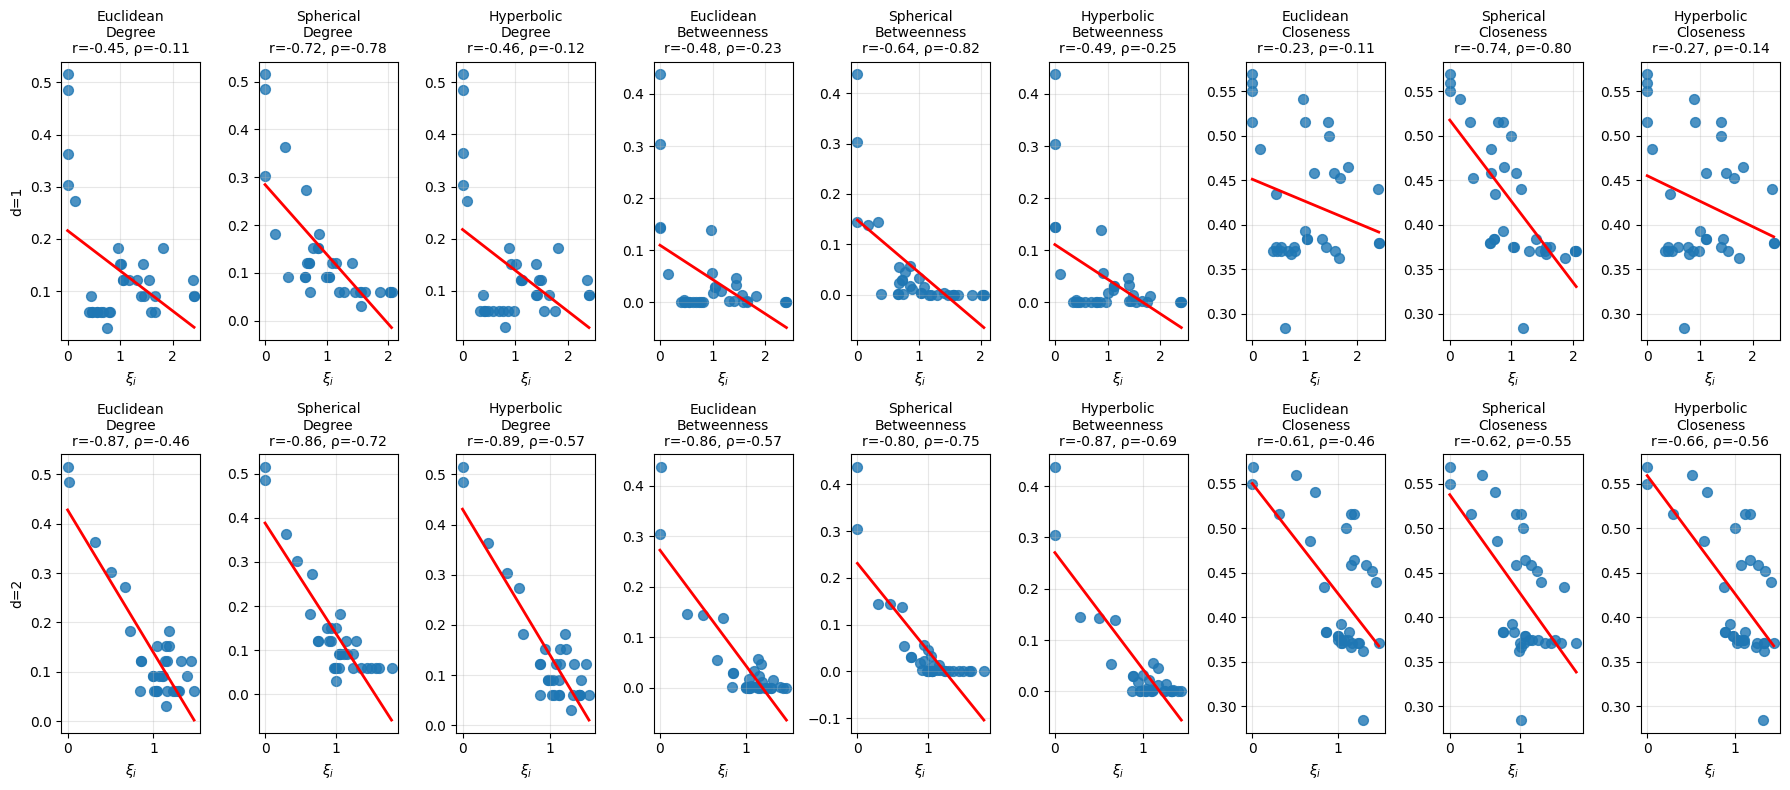

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

metrics = ["Degree", "Betweenness", "Closeness"]
geometries = ["Euclidean", "Spherical", "Hyperbolic"]
dimensions = [1, 2]

fig, axes = plt.subplots(
    len(dimensions),
    len(metrics) * len(geometries),
    figsize=(18, 8),
    sharex=False,
    sharey=False
)

for i, d in enumerate(dimensions):

    for j, metric in enumerate(metrics):

        for k, geom in enumerate(geometries):

            ax = axes[i, 3*j + k]

            # --------------------------------------------
            # xi
            # --------------------------------------------

            xi = np.asarray(
                results[(geom, d, "Weighted")]
                ["inferred"]["MAP"]['final_params']["xi"]
            )

            # --------------------------------------------
            # observed centrality
            # --------------------------------------------

            y = centrality_obs.sort_values("Node")[metric].values

            # --------------------------------------------
            # correlations
            # --------------------------------------------

            r = pearsonr(xi, y)[0]
            rho = spearmanr(xi, y)[0]

            # --------------------------------------------
            # scatter
            # --------------------------------------------

            ax.scatter(
                xi,
                y,
                s=50,
                alpha=0.8
            )

            # regression line

            coef = np.polyfit(xi, y, 1)

            xx = np.linspace(
                xi.min(),
                xi.max(),
                100
            )

            ax.plot(
                xx,
                coef[0]*xx + coef[1],
                color="red",
                lw=2
            )

            ax.set_title(
                f"{geom}\n"
                f"{metric}\n"
                f"r={r:.2f}, ρ={rho:.2f}",
                fontsize=10
            )

            if j == 0 and k == 0:
                ax.set_ylabel(f"d={d}")

            ax.set_xlabel(r"$\xi_i$")

            ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Laplacian spectrum

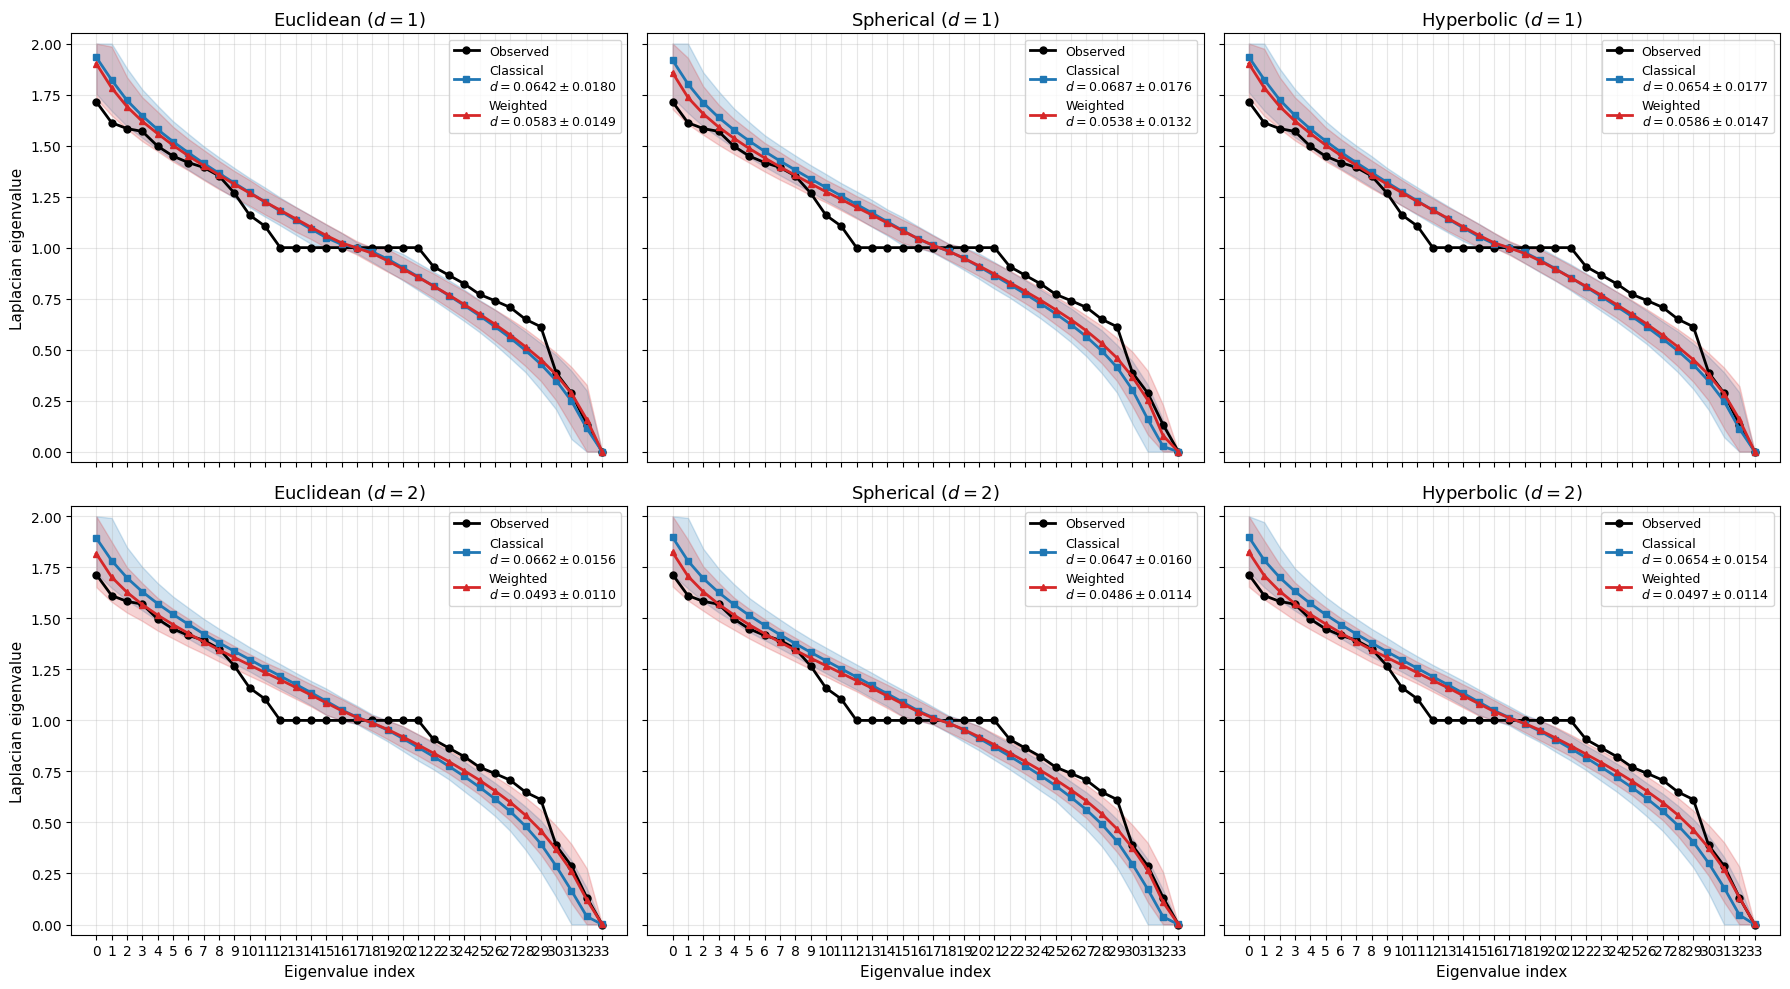

In [28]:

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Dimensions and geometries
# ==========================================================

rows = [1, 2]
cols = ["Euclidean", "Spherical", "Hyperbolic"]

# ==========================================================
# Figure
# ==========================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

for i, dim in enumerate(rows):
    for j, geom in enumerate(cols):

        ax = axes[i, j]

        # --------------------------------------------------
        # Retrieve models
        # --------------------------------------------------

        classic = results[(geom, dim, "Classical")]
        proposed = results[(geom, dim, "Weighted")]

        lap_c = classic["inferred"]["MAP"]["laplacian_validation"]
        lap_p = proposed["inferred"]["MAP"]["laplacian_validation"]

        # --------------------------------------------------
        # Reverse spectra and clip to [0, 2]
        # --------------------------------------------------

        observed = np.clip(lap_c["observed_spectrum"], 0.0, 2.0)[::-1]
        sim_c = np.clip(lap_c["simulated_spectra"], 0.0, 2.0)[:, ::-1]
        mean_c = sim_c.mean(axis=0)
        low_c  = np.percentile(sim_c, 2.5, axis=0)
        high_c = np.percentile(sim_c,97.5, axis=0)
        sim_p = np.clip(lap_p["simulated_spectra"], 0.0, 2.0)[:, ::-1]
        mean_p = sim_p.mean(axis=0)
        low_p  = np.percentile(sim_p, 2.5, axis=0)
        high_p = np.percentile(sim_p,97.5, axis=0)

        x = np.arange(len(observed))

        # --------------------------------------------------
        # Observed spectrum
        # --------------------------------------------------

        ax.plot(
            x,
            observed,
            "-o",
            color="black",
            lw=2,
            ms=5,
            label="Observed"
        )

        # --------------------------------------------------
        # Classical model
        # --------------------------------------------------

        ax.plot(
            x,
            mean_c,
            "-s",
            color="tab:blue",
            lw=2,
            ms=4,
            label=(
                "Classical\n"
                rf"$d={lap_c['mean_distance']:.4f}"
                r"\pm"
                rf"{lap_c['std_distance']:.4f}$"
            )
        )
        ax.fill_between(
            x,
            low_c,
            high_c,
            color="tab:blue",
            alpha=0.20
        )

        # --------------------------------------------------
        # Weighted model
        # --------------------------------------------------

        ax.plot(
            x,
            mean_p,
            "-^",
            color="tab:red",
            lw=2,
            ms=4,
            label=(
                "Weighted\n"
                rf"$d={lap_p['mean_distance']:.4f}"
                r"\pm"
                rf"{lap_p['std_distance']:.4f}$"
            )
        )

        ax.fill_between(
            x,
            low_p,
            high_p,
            color="tab:red",
            alpha=0.20
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------

        ax.set_title(
            f"{geom} ($d={dim}$)",
            fontsize=13
        )

        ax.set_xticks(np.arange(len(observed)))
        ax.set_xticklabels(np.arange(len(observed)))

        ax.set_ylim(-0.05, 2.05)

        ax.grid(alpha=0.30)

        if i == 1:
            ax.set_xlabel("Eigenvalue index", fontsize=11)

        if j == 0:
            ax.set_ylabel("Laplacian eigenvalue", fontsize=11)

        ax.legend(
            fontsize=9,
            frameon=True,
            loc="best"
        )

plt.tight_layout()
plt.show()

### Summary metrics

In [29]:

import pandas as pd

# =====================================================
# Build summary table
# =====================================================

rows = []

for (geometry, dimension, model), res in results.items():

    infer = res["inferred"]["MAP"]

    row = {
        "Geometry": geometry,
        "Dimension": dimension,
        "Model": model,
        "Log-Likelihood": infer["final_loglik"],
        "Log-Posterior": infer["final_logpost"],
        "BIC": infer["BIC"],
        "ROC AUC": infer["binary_prediction"]["metrics"]["roc_auc"],
        "CV Mean AUC": infer["cross_validation"]["mean_auc"],
        "CV Std AUC": infer["cross_validation"]["std_auc"],
        "Laplacian Mean Distance": infer["laplacian_validation"]["mean_distance"],
        "Laplacian Std Distance": infer["laplacian_validation"]["std_distance"],
    }

    rows.append(row)

# =====================================================
# DataFrame
# =====================================================

table = pd.DataFrame(rows)

# Order rows
geometry_order = {
    "Euclidean": 0,
    "Spherical": 1,
    "Hyperbolic": 2,
}

model_order = {
    "Classical": 0,
    "Weighted": 1,
}

table["g_order"] = table["Geometry"].map(geometry_order)
table["m_order"] = table["Model"].map(model_order)

table = (
    table
    .sort_values(["g_order", "Dimension", "m_order"])
    .drop(columns=["g_order", "m_order"])
    .reset_index(drop=True)
)

# =====================================================
# Round numbers
# =====================================================

table = table.round({
    "Log-Likelihood": 3,
    "Log-Posterior": 3,
    "BIC": 3,
    "ROC AUC": 3,
    "CV Mean AUC": 3,
    "CV Std AUC": 3,
    "Laplacian Mean Distance": 4,
    "Laplacian Std Distance": 4,
})

# =====================================================
# Display
# =====================================================

display(table)

,Geometry,Dimension,Model,Log-Likelihood,Log-Posterior,BIC,ROC AUC,CV Mean AUC,CV Std AUC,Laplacian Mean Distance,Laplacian Std Distance
0,Euclidean,1,Classical,-202.213,-202.832,625.967,0.736,0.639,0.079,0.0642,0.0180
1,Euclidean,1,Weighted,-178.507,-178.507,572.225,0.857,0.797,0.033,0.0583,0.0149
2,Euclidean,2,Classical,-130.916,-131.948,698.583,0.920,0.810,0.019,0.0662,0.0156
3,Euclidean,2,Weighted,-102.269,-102.269,419.749,0.975,0.951,0.015,0.0493,0.0110
4,Spherical,1,Classical,-164.297,-164.854,550.134,0.860,0.800,0.032,0.0687,0.0176
5,Spherical,1,Weighted,-130.771,-130.771,476.752,0.946,0.921,0.021,0.0538,0.0132
6,Spherical,2,Classical,-132.476,-133.449,701.702,0.918,0.823,0.031,0.0647,0.0160
7,Spherical,2,Weighted,-97.659,-97.659,410.529,0.984,0.965,0.015,0.0486,0.0114
8,Hyperbolic,1,Classical,-202.969,-203.599,627.477,0.735,0.734,0.051,0.0654,0.0177
9,Hyperbolic,1,Weighted,-179.863,-179.863,574.937,0.856,0.796,0.028,0.0586,0.0147
